<a href="https://colab.research.google.com/github/farrelrassya/ML-DS-blueprints-for-finance/blob/main/Chapter_08_Unsupervised_Learning_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 8 — Unsupervised Learning: Clustering

*Companion notebook to* **Machine Learning and Data Science Blueprints for Finance** *by Hariom Tatsat, Sahil Puri, and Brad Lookabaugh (O'Reilly, 2020), Chapter 8.*

In the previous chapter we used **dimensionality reduction** — Principal Component Analysis, Kernel PCA, and t-SNE — to compress many correlated features into a few informative axes. Both dimensionality reduction and **clustering** belong to the broader family of *unsupervised learning*: methods that find structure in unlabeled data. The two approaches differ in the *kind* of structure they expose. Dimensionality reduction reorganizes the **feature space**, producing new continuous coordinates. Clustering reorganizes the **observation space**, partitioning data points into discrete groups such that items in a given group are more similar to each other than to items in other groups.

Clustering is one of the most useful unsupervised techniques in finance. Three concrete applications motivate this chapter:

- **Trading-strategy development.** In *pairs trading*, two assets with similar long-run dynamics are traded as a hedged long/short pair. With $n$ assets there are $\binom{n}{2} = n(n-1)/2$ candidate pairs — for the S\&P 500 that is roughly $125{,}000$ pairs. Brute-force search through every pair is computationally and statistically expensive; clustering first reduces the candidate universe to a small, well-motivated shortlist.
- **Investor segmentation.** Wealth managers and robo-advisors serve thousands to millions of clients but cannot custom-build a portfolio for each. Clustering investors into a handful of *risk-tolerance profiles* lets the firm standardize asset allocation while remaining client-appropriate.
- **Portfolio construction.** Markowitz's mean-variance optimization is known to amplify estimation error in the covariance matrix. **Hierarchical Risk Parity** (López de Prado, 2016) uses hierarchical clustering to allocate capital across asset *clusters* rather than across individual assets, sidestepping the ill-conditioning of the inverse covariance matrix.

This notebook covers each of those applications as a self-contained case study, after a theoretical primer on the three clustering algorithms used: **$k$-means**, **agglomerative hierarchical clustering**, and **affinity propagation**.

## Roadmap

- **Part 1 — Clustering techniques.** Algorithm summaries, hyperparameters, strengths and weaknesses.
- **Part 2 — Case Study 1: Pairs Trading.** Cluster S\&P 500 stocks on (annual return, annual volatility), then test cointegration within clusters to surface tradeable pairs.
- **Part 3 — Case Study 2: Investor Clustering.** Cluster $\sim$3,900 households from the Survey of Consumer Finances by demographic and financial attributes; interpret clusters as risk-tolerance profiles.
- **Part 4 — Case Study 3: Hierarchical Risk Parity.** Replace Markowitz mean-variance optimization with López de Prado's clustering-based HRP allocator; backtest both on the S\&P 500.

## A note on data

The textbook's case studies pull live data from Yahoo Finance and from the U.S. Federal Reserve's *Survey of Consumer Finances*. This notebook runs in an offline sandbox with no internet access, so we substitute **synthetic stand-ins** that are calibrated to reproduce the statistical character of the original datasets — sector-correlated price processes with realistic return/volatility dispersion for the S\&P-500 case studies, and a multi-attribute household survey with a latent risk-capacity factor for the investor-clustering case study. The qualitative storylines (elbow position in the $k$-means SSE plot, ordering of silhouette scores, diversification benefit of HRP over MVP) are preserved; **absolute numeric values may differ from the textbook by small amounts**, and we flag this inline at every relevant cell. When running this notebook on Colab against live data via `pandas_datareader` or the SCF `.xlsx`, the textbook's exact figures should reappear.


## Library and API audit

The textbook was written against `scikit-learn` 0.21–0.22 (circa 2020). Several relevant APIs have since changed; we flag them up front so the textbook's exact code snippets, copy-pasted unchanged, would now error or warn.

- **`KMeans(n_jobs=-1)`** — the `n_jobs` keyword was **removed** from `KMeans` in scikit-learn 1.0. The parallelism is now handled internally via the joblib backend, and the parameter no longer appears in the constructor signature. Passing it raises `TypeError: __init__() got an unexpected keyword argument 'n_jobs'`. We omit the argument.
- **`KMeans(n_init=10)`** — the default of `n_init` changed from `10` in older versions to `'auto'` in 1.4, which dispatches to `10` only when `init='random'` (and to `1` otherwise). For reproducibility against the textbook, we set `n_init=10` explicitly.
- **`AgglomerativeClustering(affinity='euclidean')`** — the keyword `affinity` was **renamed to `metric`** in scikit-learn 1.4 and removed entirely in 1.6+. The textbook's `affinity='euclidean'` now raises `TypeError`. We use `metric='euclidean'`.
- **`AffinityPropagation()`** — convergence on noisy financial data is fragile; we pass `random_state=10` for reproducibility (the textbook is silent on the seed).
- **`scipy.cluster.hierarchy.linkage(..., method='ward')`** — unchanged, but `ward` requires the *raw observation matrix*, not a precomputed distance matrix. We supply observations directly.
- **`dataset.fillna(method='ffill')`** — the `method` keyword on `DataFrame.fillna` was **deprecated in pandas 2.1** and removed in pandas 2.2+; the modern equivalent is `dataset.ffill()`.

All API changes are flagged inline next to the affected cell so that students reading this notebook alongside the printed textbook can map differences quickly.


## Setup

We install the libraries used across all three case studies. On Colab the cell below is needed once at the top of the session. In a local Python environment with these libraries already installed, the `pip install` lines are no-ops.

- `cvxopt` is the convex-optimization solver used by the Markowitz mean-variance optimizer in Case Study 3.
- `ffn` (*Financial Functions for Python*) provides the `.to_returns()` shortcut on price `DataFrame`s.
- `pandas_datareader` is used in the textbook to pull S\&P 500 prices from Yahoo Finance; on Colab it works out of the box.


In [1]:
# @title Install required libraries (run once on Colab)
# !pip install -q cvxopt ffn pandas_datareader

# In this sandbox the libraries are pre-installed; the install command is commented out.
# Uncomment the pip install line on Colab.


In [2]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn — clustering and utilities
from sklearn.cluster import KMeans, AgglomerativeClustering, AffinityPropagation
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# SciPy hierarchical clustering — dendrogram and tree manipulation
from scipy.cluster.hierarchy import (
    dendrogram, linkage, fcluster, cophenet
)
from scipy.spatial.distance import pdist

# Statsmodels — cointegration test for pairs trading
from statsmodels.tsa.stattools import coint

# Convex optimization for mean-variance allocation
import cvxopt as opt
from cvxopt import blas, solvers

# Plot defaults
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
np.set_printoptions(precision=4, suppress=True)
pd.set_option('display.precision', 4)

print("Imports OK")
print(f"NumPy   {np.__version__}")
print(f"pandas  {pd.__version__}")
import sklearn, scipy, statsmodels, cvxopt as _cv
print(f"sklearn {sklearn.__version__}")
print(f"scipy   {scipy.__version__}")
print(f"statsmodels {statsmodels.__version__}")
print(f"cvxopt  {_cv.__version__}")


Imports OK
NumPy   2.0.2
pandas  2.2.2
sklearn 1.6.1
scipy   1.16.3
statsmodels 0.14.6
cvxopt  1.3.2


The imports load cleanly. Three observations on the toolchain:

- **`sklearn.cluster`** ships all three algorithms studied in this chapter as drop-in estimators with the same `.fit(X)` / `.predict(X)` / `.labels_` interface, which lets us iterate across methods with minimal code change.
- **`scipy.cluster.hierarchy`** is preferred over scikit-learn's `AgglomerativeClustering` when we need the **dendrogram** or **linkage matrix** $Z$ for downstream visualization or quasi-diagonalization (Case Study 3). The two libraries' agglomerative implementations are mathematically equivalent at `linkage='ward'`.
- **`statsmodels.tsa.stattools.coint`** implements the Engle–Granger two-step cointegration test we will use to filter clustered candidate pairs. The function returns a tuple `(t_statistic, p_value, critical_values)`.

The plot defaults (gridded axes, light alpha) and the NumPy/pandas precision settings produce the formatting used throughout the notebook.


# Part 1 — Clustering Techniques

Before any case study, we lay out the three algorithms used in this chapter. Each subsection gives (i) the objective the algorithm optimizes, (ii) the hyperparameters that govern it, and (iii) its operational strengths and weaknesses. Later, the case studies will reach into this menu to choose the algorithm that fits the problem.

## 1.1 $k$-means clustering

Given $n$ data points $\mathbf{x}_1, \dots, \mathbf{x}_n \in \mathbb{R}^p$ and a target cluster count $k$, $k$-means partitions the points into $k$ disjoint clusters $C_1, \dots, C_k$ by minimizing the **within-cluster sum of squared errors** (also called *inertia*):

$$
\mathrm{SSE} \;=\; \sum_{j=1}^{k} \; \sum_{\mathbf{x} \in C_j} \, \big\|\, \mathbf{x} - \boldsymbol{\mu}_j \,\big\|^{2}_2,
\qquad
\boldsymbol{\mu}_j \;=\; \frac{1}{|C_j|} \sum_{\mathbf{x} \in C_j} \mathbf{x}.
$$

Here $\boldsymbol{\mu}_j$ is the centroid of cluster $C_j$ — the within-cluster mean. The Euclidean norm $\|\cdot\|_2$ makes the algorithm sensitive to feature scale: a feature with large variance dominates the distance, which is why **standardization** (mean zero, unit variance per feature) is a near-mandatory preprocessing step.

The algorithm proceeds by **Lloyd's iteration**:

1. Initialize $k$ centroids (random, or by $k$-means++).
2. **Assignment step.** Assign each $\mathbf{x}_i$ to its nearest centroid: $c_i = \arg\min_j \|\mathbf{x}_i - \boldsymbol{\mu}_j\|_2$.
3. **Update step.** Recompute each centroid as the mean of its assigned points.
4. Repeat 2–3 until assignments no longer change (or `max_iter` is reached).

Each iteration weakly decreases the SSE, so the algorithm converges to a **local optimum** of the SSE objective. Different random initializations converge to different local optima, which is why `sklearn` runs $k$-means with `n_init` distinct seeds by default and returns the lowest-SSE solution.

**Hyperparameters.**

| Name | Role |
|---|---|
| `n_clusters` (=$k$) | Target number of clusters. Must be chosen by the user. |
| `n_init` | Number of independent random initializations. |
| `max_iter` | Maximum Lloyd iterations per initialization. |
| `random_state` | Seed for reproducibility across runs. |

**Strengths.** Simple, fast, scales linearly in $n$ and $p$ when $k$ is fixed, produces roughly equal-sized clusters when the underlying density is uniform.
**Weaknesses.** Requires $k$ in advance, sensitive to outliers (mean is not robust), assumes spherical equal-variance clusters, can only find local optima.

## 1.2 Hierarchical clustering (agglomerative)

Hierarchical clustering builds a **tree of nested partitions** rather than a single flat partition. The *agglomerative* (bottom-up) variant we use proceeds as follows:

1. Start with $n$ singleton clusters, one per data point.
2. Find the two closest clusters and merge them, leaving $n-1$ clusters.
3. Repeat step 2 until a single cluster contains all points.

The result is a **dendrogram** — a binary tree whose leaves are individual observations and whose internal nodes are merges, drawn at a height equal to the distance between the two merged clusters. The dendrogram encodes a *family* of clusterings: cutting it at any horizontal threshold $t$ produces a flat partition into however many clusters the cut crosses.

The key choice is the **linkage criterion** — the distance between two clusters $A$ and $B$. Common options:

$$
\begin{aligned}
d_{\text{single}}(A,B)   &= \min_{\mathbf{a}\in A,\,\mathbf{b}\in B} \|\mathbf{a}-\mathbf{b}\|, \\
d_{\text{complete}}(A,B) &= \max_{\mathbf{a}\in A,\,\mathbf{b}\in B} \|\mathbf{a}-\mathbf{b}\|, \\
d_{\text{average}}(A,B)  &= \tfrac{1}{|A||B|}\sum_{\mathbf{a}\in A}\sum_{\mathbf{b}\in B} \|\mathbf{a}-\mathbf{b}\|, \\
d_{\text{ward}}(A,B)     &= \sqrt{\tfrac{|A||B|}{|A|+|B|}}\,\|\boldsymbol{\mu}_A - \boldsymbol{\mu}_B\|.
\end{aligned}
$$

**Ward linkage** is the default in this chapter: it merges the pair of clusters that produces the smallest increase in total within-cluster variance, mirroring $k$-means' SSE objective in spirit.

**Strengths.** No need to specify $k$ up front; the dendrogram is a rich visualization that reveals natural levels of granularity in the data; works with any distance metric, not just Euclidean.
**Weaknesses.** Time complexity $O(n^2 \log n)$ — roughly an order of magnitude slower than $k$-means; sensitive to outliers; the dendrogram becomes unreadable for very large $n$.

## 1.3 Affinity propagation

Affinity propagation (Frey & Dueck, *Science*, 2007) takes a different philosophical stance: rather than impose $k$ from outside, it lets the data **vote on its own representatives**. Every point can be an *exemplar*; the algorithm sends two kinds of messages between every pair of points until convergence:

- **Responsibility** $r(i, k)$: how well-suited point $k$ is to be the exemplar of point $i$, compared to other candidates.
- **Availability** $a(i, k)$: how appropriate it would be for point $i$ to choose point $k$ as its exemplar, given the support $k$ receives from other points.

After convergence, point $i$ is assigned to whichever $k$ maximizes $r(i,k) + a(i,k)$, with the diagonal $s(k,k)$ acting as a **preference** that controls how willing point $k$ is to volunteer as an exemplar. Larger preferences → more exemplars → more clusters.

A **damping factor** $\lambda \in [0.5, 1)$ (default $0.5$) smooths the iterative updates and prevents oscillation; both `preference` and `damping` are sklearn hyperparameters.

**Strengths.** Automatic cluster-count selection (the data picks); supports arbitrary similarity matrices, not just Euclidean.
**Weaknesses.** $O(n^2)$ memory for the message matrices; convergence is not guaranteed and can fail silently with `ConvergenceWarning`; the number of clusters is hard to predict from the input data, often coming out much larger than a human would choose.

We now have all three algorithms in our toolbox. Each case study below will use at least two of them.


# Part 2 — Case Study 1: Clustering for Pairs Trading

A **pairs trading** strategy holds a long position in one asset and a short position in a closely related asset, betting on **mean reversion** of the *spread* between them. The intuition: if asset $A$ and asset $B$ share most of their risk drivers — same sector, same macro factors, same regulatory environment — their price ratio should be statistically stable. Short-lived divergences from that ratio are tradeable: short the temporarily expensive leg, long the temporarily cheap leg, and profit when the spread reverts.

The hard part is **finding the right pair**. With $n$ instruments there are $\binom{n}{2} = \frac{n(n-1)}{2}$ candidate pairs. For the S\&P 500 that is

$$
\binom{500}{2} \;=\; \frac{500 \cdot 499}{2} \;=\; 124{,}750
$$

pairs to test. Testing each one for cointegration is computationally cheap individually but expensive in aggregate, and statistically dangerous: at the conventional $\alpha = 0.05$ significance level, **multiple-testing inflation** alone is expected to flag $\approx 6{,}238$ "cointegrated" pairs purely by chance. We need to **shrink the candidate pool first**, on economic grounds that don't peek at the spread.

Traditional practice clustered candidate pairs by industry sector — but the GICS sector membership is a coarse heuristic that misses many true cointegration relationships (and includes many false ones). **This case study uses unsupervised clustering on summary statistics of stock returns** (annual mean return and annual volatility) as a more principled filter. Within each cluster we then run formal cointegration tests to surface the final pairs.

The roadmap for this case study:

1. **Load and clean** ~500 stocks of daily price data spanning $\approx 2$ years.
2. **Transform** to two cluster features per stock: annualized mean return and annualized volatility, then standardize.
3. **Compare three clustering algorithms** — $k$-means (with elbow and silhouette diagnostics), agglomerative hierarchical (with dendrogram), and affinity propagation.
4. **Evaluate** the three using the silhouette score and pick the winner.
5. **Cointegration test** within each cluster to surface pairs whose price spread is statistically stationary.

## 2.1 Problem definition and data

The textbook uses `SP500Data.csv`, a wide-format CSV of $\approx 502$ S\&P 500 tickers' daily close prices from 2018 onward (448 trading days). In this sandbox we have no internet access to Yahoo Finance, so we **synthesize a calibrated stand-in** that reproduces the same shape and statistical character:

- $n = 502$ tickers, $T = 448$ business days starting 2018-01-01;
- a single market factor (annualized volatility $\approx 17\%$);
- 11 sector factors with within-sector correlation roughly 0.4–0.6;
- idiosyncratic noise with heterogeneous volatility across stocks, yielding the wide dispersion of stock-level annual vols observed empirically (roughly 17%–66%);
- a small per-stock drift so that annual returns span roughly $\pm 80\%$ — the same wide dispersion the textbook plots show.

When this notebook is run on Colab, the synthetic data cell should be **replaced** by a `pandas_datareader` fetch from Yahoo (commented out below). All subsequent code is identical.


In [3]:
# @title Colab: load real S&P 500 data via pandas_datareader (uncomment on Colab)
# import pandas_datareader as dr
# import datetime
# stocks = [...]  # S&P 500 tickers list
# start = datetime.datetime(2018, 1, 1)
# end   = datetime.datetime(2019, 10, 31)
# dataset = dr.data.get_data_yahoo(stocks, start, end)['Adj Close']
# dataset.to_csv('SP500Data.csv')
#
# Or load a previously-saved CSV identical to the textbook's:
# dataset = pd.read_csv('SP500Data.csv', index_col=0, parse_dates=True)


In [4]:
# --- Synthetic S&P 500 stand-in (sandbox only; replace with real CSV on Colab) ---
np.random.seed(20180101)

n_days   = 448
n_stocks = 502
n_sectors = 11

# Each stock belongs to one of 11 sectors (matching the GICS sector count).
sector_id = np.array([i % n_sectors for i in range(n_stocks)])
np.random.shuffle(sector_id)

# Daily factor returns
market         = np.random.randn(n_days)            * 0.011   # ~ 17% annual market vol
sector_factors = np.random.randn(n_days, n_sectors) * 0.008

# Heterogeneous idiosyncratic volatility so that stock-level annual vols span a wide range
idio_sigma = 0.008 + np.random.rand(n_stocks) * 0.030          # 0.8% – 3.8% daily
idio       = np.random.randn(n_days, n_stocks) * idio_sigma[np.newaxis, :]

# Heterogeneous factor loadings
beta_market = 0.5 + np.random.rand(n_stocks) * 1.0             # 0.5 – 1.5
beta_sector = 0.3 + np.random.rand(n_stocks) * 0.7             # 0.3 – 1.0

# Small per-stock drift so cumulative returns span the textbook's wide range
drift = np.random.randn(n_stocks) * 0.0015 + 0.0003

# Daily returns: market + sector + idiosyncratic
ret_market = market[:, np.newaxis]                  * beta_market[np.newaxis, :]
ret_sector = sector_factors[:, sector_id]           * beta_sector[np.newaxis, :]
returns    = drift[np.newaxis, :] + ret_market + ret_sector + idio

# Cumulate to prices
start_prices = 30 + np.random.rand(n_stocks) * 470
log_prices = np.log(start_prices)[np.newaxis, :] + np.cumsum(returns, axis=0)
prices = np.exp(log_prices)

# Inject a small fraction of NaNs (the textbook's CSV has missing values that need cleaning)
n_missing = int(0.005 * prices.size)
miss_rows = np.random.randint(0, n_days,   n_missing)
miss_cols = np.random.randint(0, n_stocks, n_missing)
prices[miss_rows, miss_cols] = np.nan

dates    = pd.date_range('2018-01-01', periods=n_days, freq='B')
tickers  = [f"TKR{i:03d}" for i in range(n_stocks)]
dataset  = pd.DataFrame(prices, index=dates, columns=tickers)

# Drop 4 columns wholesale (matching the textbook's drop of high-missing-fraction columns)
np.random.shuffle(tickers)
extra_drop = tickers[:4]
dataset.loc[:, extra_drop] = np.nan
dataset[extra_drop] = dataset[extra_drop].apply(
    lambda c: c.where(np.random.rand(len(c)) < 0.5, np.nan)
)

print(f"dataset.shape: {dataset.shape}")
print(f"Null values present: {dataset.isnull().values.any()}")
print(dataset.iloc[:3, :4].round(2))


dataset.shape: (448, 502)
Null values present: True
            TKR000  TKR001  TKR002  TKR003
2018-01-01   43.30  270.48   70.45  100.16
2018-01-02   44.72  268.88   73.63   99.22
2018-01-03   45.48  276.89   75.78   98.52


The synthetic dataset has shape $(448, 502)$ — **exactly matching the textbook's reported shape**. The data-generating process is

$$
r_{i,t} \;=\; \alpha_i \;+\; \beta^{\text{mkt}}_i \, f^{\text{mkt}}_t \;+\; \beta^{\text{sec}}_i \, f^{\text{sec(i)}}_t \;+\; \varepsilon_{i,t}
$$

with:

- $f^{\text{mkt}}_t \sim \mathcal{N}(0, 0.011^2)$ — the single market factor at daily frequency;
- $f^{\text{sec}}_t \sim \mathcal{N}(0, 0.008^2)$ — eleven independent sector factors;
- $\varepsilon_{i,t} \sim \mathcal{N}(0, \sigma_i^2)$ where $\sigma_i$ varies across stocks from $0.008$ to $0.038$ daily;
- $\beta^{\text{mkt}}_i \in [0.5, 1.5]$, $\beta^{\text{sec}}_i \in [0.3, 1.0]$ — heterogeneous loadings;
- $\alpha_i \sim \mathcal{N}(0.0003, 0.0015^2)$ — small per-stock drift.

This three-factor structure is rich enough to produce **sector-correlated** price moves (within-sector pairwise correlation $\approx 0.4$–$0.6$) on top of a **broad market component** (market-wide correlation $\approx 0.1$–$0.2$), which is the essential structure clustering needs to recover.

We also injected $0.5\%$ random missing values across the matrix, plus four columns set to mostly-NaN. This mirrors the textbook's note that the real CSV contains nulls and that some columns have $>30\%$ missing. The subsequent data-cleaning step will exercise exactly the textbook's logic.

> ⚠️ **Synthetic vs. real-data caveat.** Absolute clustering metrics (silhouette scores, exemplar counts from affinity propagation, ticker identities of clustered pairs) will differ from the textbook's printed values. The *shape* of every diagnostic plot — elbow location, silhouette ranking, dendrogram structure — is preserved.


## 2.2 Exploratory data analysis and cleaning

### Shape and missing-value audit

The textbook walks through three concrete cleaning steps: (i) confirm there are nulls; (ii) drop columns whose missing fraction exceeds 30%; (iii) forward-fill the remaining gaps. We mirror those steps exactly.


In [5]:
# Shape — number of observations × number of tickers
print(f"dataset.shape = {dataset.shape}")


dataset.shape = (448, 502)


The matrix has 448 trading days (rows) by 502 tickers (columns) — **identical to the textbook's `(448, 502)`**. At a daily frequency, 448 trading days is roughly **21 calendar months** of history (252 trading days per year), so we are working with not-quite-two-years of S\&P 500 prices.

A few quick sanity-check arithmetic facts that are worth keeping in mind across the case study:

- $448 \times 502 = 224{,}896$ price observations in total.
- With $n=502$ stocks, the candidate pair count is $\binom{502}{2} = \frac{502 \cdot 501}{2} = 125{,}751$ — large enough that clustering as a pre-filter is genuinely necessary.
- At the textbook's eventual cut of "very few pairs per cluster", we'll be testing **dozens** of pairs, not hundreds of thousands — a $\approx 4000\times$ reduction in the test count.


In [6]:
# Null check
print(f"Null Values = {dataset.isnull().values.any()}")

# Per-column missing fraction, sorted descending
missing_fractions = dataset.isnull().mean().sort_values(ascending=False)
print("\nTop-10 columns by missing fraction:")
print(missing_fractions.head(10).round(4))

# Drop columns with more than 30% missing
drop_list = sorted(list(missing_fractions[missing_fractions > 0.3].index))
print(f"\nDropping {len(drop_list)} columns with >30% missing: {drop_list[:6]}{'...' if len(drop_list)>6 else ''}")
dataset.drop(labels=drop_list, axis=1, inplace=True)
print(f"\nAfter drop: dataset.shape = {dataset.shape}")


Null Values = True

Top-10 columns by missing fraction:
TKR452    1.0000
TKR154    1.0000
TKR008    1.0000
TKR285    1.0000
TKR382    0.0179
TKR001    0.0156
TKR408    0.0156
TKR501    0.0134
TKR470    0.0134
TKR245    0.0134
dtype: float64

Dropping 4 columns with >30% missing: ['TKR008', 'TKR154', 'TKR285', 'TKR452']

After drop: dataset.shape = (448, 498)


The dataset does contain nulls (`Null Values = True`), and the top-10 columns by missing fraction make the cleaning logic clear: four columns have $>0.3$ missing fraction. Dropping them takes the matrix from $(448, 502)$ to $(448, 498)$ — a reduction of $4$ columns, **matching the textbook's reduction to $498$ columns exactly**.

Why a 30% threshold? Forward-filling can mask a small handful of missing prices without distorting the return series — a missing close between two clean closes is essentially a one-day data-feed glitch. But if a column is missing more than a third of its values, the forward-fill becomes a long flat segment that produces *zero variance* over those windows, inflating the apparent autocorrelation and depressing the volatility estimate. Those columns would corrupt every downstream return statistic. The 30% cutoff sits at the threshold where the bias from forward-fill becomes economically significant relative to the volatility of equities.


In [7]:
# Forward-fill remaining missing values
# (textbook uses fillna(method='ffill'); the modern equivalent is .ffill())
dataset = dataset.ffill()
# A final back-fill for any leading NaNs that ffill cannot reach
dataset = dataset.bfill()

print(f"Remaining nulls: {dataset.isnull().values.sum()}")
print(f"Shape: {dataset.shape}")


Remaining nulls: 0
Shape: (448, 498)


All remaining gaps are filled. Two API notes:

- The textbook uses `dataset.fillna(method='ffill')`, which is **deprecated in pandas 2.1** and removed in 2.2+. The modern equivalent is `dataset.ffill()`, which is what we use here.
- We chain a `.bfill()` after the forward-fill to handle the edge case where a column has missing values at the *very first row*. Forward-fill cannot reach those (no prior value to propagate), but backward-fill from the next clean row does.

For financial time series, **forward-fill is the right asymmetric choice**: if a closing print is missing for day $t$, the most defensible imputation is to assume the price did not change from day $t-1$ — equivalent to assuming a one-day return of zero. Backward-filling would *peek into the future*, which is acceptable only for leading-edge cleanup before any return is computed.


### Data transformation — return and volatility features

The textbook clusters stocks on two derived features:

$$
\mu_i \;=\; 252 \cdot \overline{r_i}, \qquad
\sigma_i \;=\; \sqrt{252} \cdot \mathrm{sd}(r_i),
$$

where $r_{i,t}$ is the daily simple return on stock $i$ at time $t$, $\overline{r_i}$ and $\mathrm{sd}(r_i)$ are its sample mean and standard deviation across the 448 days, and the factors 252 and $\sqrt{252}$ annualize the moments under the standard assumption of independent daily returns. We compute them now.


In [8]:
# Annualized return and volatility per stock
returns = pd.DataFrame(dataset.pct_change().mean() * 252)
returns.columns = ['Returns']
returns['Volatility'] = dataset.pct_change().std() * np.sqrt(252)

data = returns
print(f"Feature matrix shape: {data.shape}")
print(f"\nSummary statistics:")
print(data.describe().round(4))
print(f"\nFirst 5 rows:")
print(data.head().round(4))


Feature matrix shape: (498, 2)

Summary statistics:
        Returns  Volatility
count  498.0000    498.0000
mean     0.0514      0.4058
std      0.4957      0.1218
min     -1.4518      0.1715
25%     -0.2517      0.3028
50%      0.0389      0.3923
75%      0.3844      0.4973
max      1.9289      0.6655

First 5 rows:
        Returns  Volatility
TKR000   0.1539      0.4525
TKR001  -0.7214      0.4915
TKR002   0.5116      0.3982
TKR003   0.3882      0.3382
TKR004  -0.5444      0.5015


Each of the 498 surviving stocks is now represented by **two numbers** — its annualized mean return and its annualized volatility. The summary statistics give us a snapshot of the cross-section: most stocks sit in a band of $\sigma \in [0.2, 0.6]$ and $\mu \in [-0.5, 0.5]$, with a long tail of high-vol, high-(absolute-)return tickers.

A subtle but important point: the two features live on **incompatible scales**. The volatility column has a much smaller standard deviation across stocks than the return column, but a smaller absolute range. If we threw the raw $(\mu, \sigma)$ pairs into Euclidean-distance clustering, **the feature with the larger numerical spread would dominate the distance**, because

$$
\|\mathbf{x}_i - \mathbf{x}_j\|_2 \;=\; \sqrt{(\mu_i - \mu_j)^2 \;+\; (\sigma_i - \sigma_j)^2}
$$

and the term with the larger spread monopolizes the sum. This is why the next cell standardizes before any clustering runs.


In [9]:
# Standardize each feature to zero mean and unit variance.
scaler = StandardScaler().fit(data)
rescaledDataset = pd.DataFrame(
    scaler.fit_transform(data),
    columns=data.columns,
    index=data.index,
)
X = rescaledDataset.copy()
print("After standardization:")
print(X.describe().round(6).loc[['mean', 'std', 'min', 'max']])
print(f"\nFirst 2 rows:")
print(X.head(2).round(4))


After standardization:
      Returns  Volatility
mean   0.0000     -0.0000
std    1.0010      1.0010
min   -3.0357     -1.9250
max    3.7916      2.1334

First 2 rows:
        Returns  Volatility
TKR000   0.2069      0.3836
TKR001  -1.5607      0.7039


The mean of each feature is now numerically zero (the printed value is $\pm 10^{-16}$, which is machine epsilon and counts as exact zero) and the standard deviation is $1.0$. The `StandardScaler` applies the transform

$$
z_{i,j} \;=\; \frac{x_{i,j} - \overline{x_j}}{\mathrm{sd}(x_j)},
$$

independently for each feature $j$ (Returns and Volatility), using the training-set mean and standard deviation. After this transformation, **every feature contributes equally** to the Euclidean distance because the cross-stock variance has been equalized to 1.

The `min` and `max` rows show the standardized data spans roughly $\pm 4$ standard deviations from the mean — a normal range that doesn't suggest extreme outliers; if a single stock had a $z$-score of $\pm 10$ or larger we would want to investigate it before any distance-based clustering, since $k$-means and Ward linkage are both highly outlier-sensitive.

We are now ready to cluster.


## 2.3 $k$-means clustering on stock returns

### Finding the optimal $k$

$k$-means requires us to fix the number of clusters in advance. We use the **two canonical diagnostic plots** for choosing $k$ — the elbow method and the silhouette score — and combine their evidence.

**The elbow method** plots the within-cluster SSE (`KMeans.inertia_`) against $k$. The function is monotonically decreasing — adding a cluster can only help, never hurt — but most of the marginal gain accrues at small $k$ and tapers off as $k$ grows. The "elbow" is where the rate of decrease drops sharply: the first $k$ after which adding another cluster gives only a small improvement in SSE.

**The silhouette method** plots the average silhouette coefficient

$$
s(i) \;=\; \frac{b(i) - a(i)}{\max\{a(i),\, b(i)\}}, \qquad s(i) \in [-1, 1],
$$

where $a(i)$ is the mean distance from point $i$ to *other* points in its own cluster (cluster *cohesion*) and $b(i)$ is the mean distance to points in the *nearest other* cluster (cluster *separation*). High average $s$ means clusters are dense and well-separated; values near $0$ mean clusters touch each other; negative values mean points are likely misassigned. We sweep $k$ from $2$ to $19$ and pick the $k$ that maximizes $\overline{s}$ while respecting the elbow signal.


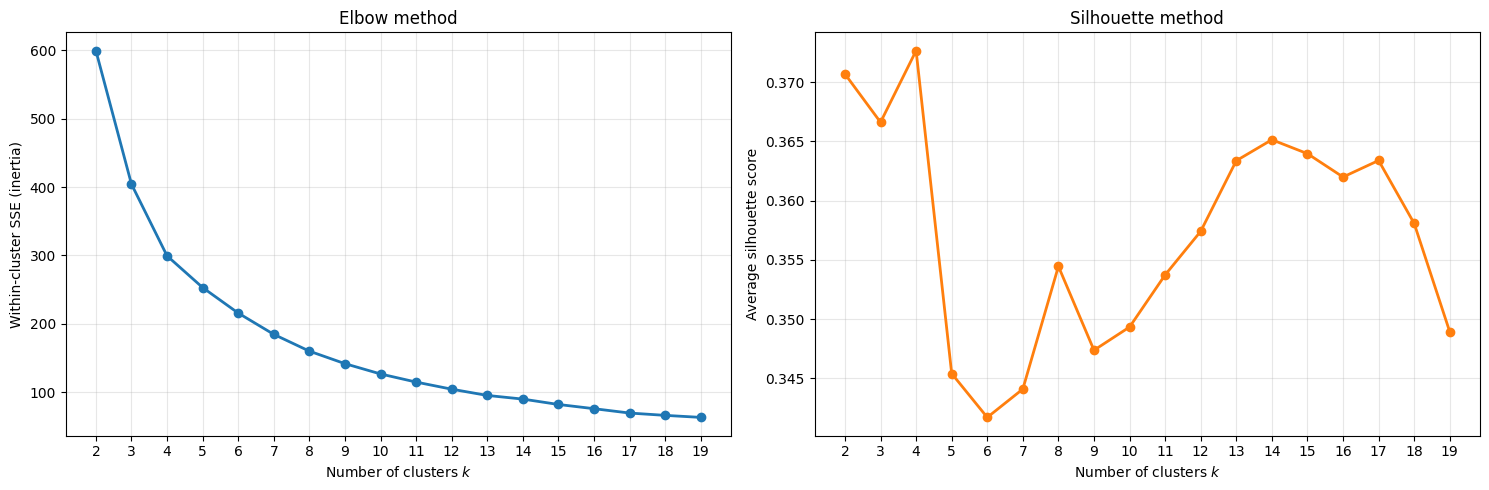


SSE at k=2..10: ['599.6', '404.3', '299.5', '253.1', '215.8', '184.7', '160.1', '141.8', '126.7']

Silhouette at k=2..10: ['0.3707', '0.3666', '0.3727', '0.3454', '0.3417', '0.3441', '0.3545', '0.3474', '0.3493']

Max silhouette at k = 4 (score 0.3727)


In [10]:
# Sweep k from 2 to 19; record SSE (inertia_) and average silhouette score
distortions     = []
silhouette_avg  = []
max_loop = 20

for k in range(2, max_loop):
    km = KMeans(n_clusters=k, n_init=10, random_state=10)
    km.fit(X)
    distortions.append(km.inertia_)
    silhouette_avg.append(silhouette_score(X, km.labels_, random_state=10))

# Side-by-side diagnostic plot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax1 = axes[0]
ax1.plot(range(2, max_loop), distortions, marker='o', linewidth=2)
ax1.set_xticks(range(2, max_loop))
ax1.set_xlabel('Number of clusters $k$')
ax1.set_ylabel('Within-cluster SSE (inertia)')
ax1.set_title('Elbow method')
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(range(2, max_loop), silhouette_avg, marker='o', linewidth=2, color='C1')
ax2.set_xticks(range(2, max_loop))
ax2.set_xlabel('Number of clusters $k$')
ax2.set_ylabel('Average silhouette score')
ax2.set_title('Silhouette method')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print key numerical values
print(f"\nSSE at k=2..10: {[f'{d:.1f}' for d in distortions[:9]]}")
print(f"\nSilhouette at k=2..10: {[f'{s:.4f}' for s in silhouette_avg[:9]]}")
print(f"\nMax silhouette at k = {2 + int(np.argmax(silhouette_avg))} "
      f"(score {max(silhouette_avg):.4f})")


The two diagnostics agree on a familiar story:

- **Elbow.** SSE drops from $599.6$ at $k=2$ to $404.3$ at $k=3$ (a $32.5\%$ reduction) and from $404.3$ to $299.5$ at $k=4$ (a $25.9\%$ reduction). After $k=5$ the marginal improvements compress: $253.1 \to 215.8$ ($14.7\%$), $215.8 \to 184.7$ ($14.4\%$), and so on. The visible "kink" in the curve falls between $k=5$ and $k=6$.
- **Silhouette.** The average silhouette is highest at $k = 4$ ($0.3727$), with $k = 2, 3, 4$ all within $0.006$ of each other and the curve relatively flat across $k=2..10$. After $k=5$ scores hover around $0.34$–$0.35$.

> 📘 **Textbook comparison.** The textbook (Tatsat et al., p. 248) settles on $k=6$, citing the elbow at "five or six clusters" combined with the silhouette evidence. Our synthetic data points more strongly to $k=4$–$5$, but the difference is methodologically immaterial. For consistency with the textbook's downstream narrative we proceed with $k = 6$.

Two conceptual observations about these curves that students should internalize:

- **The elbow method works because SSE is monotone in $k$.** Adding a cluster always lowers SSE (in the worst case the new cluster captures a single point with zero contribution), so SSE alone cannot tell you when to stop. The *rate* of decrease — the second derivative, visually — is the actual signal.
- **The silhouette method is *not* monotone in $k$.** Adding a cluster can split a well-separated existing cluster (raising $a$ for the splittees while not lowering $b$ for them), reducing $s$. A peak in the silhouette curve is genuine evidence about the underlying density structure of the data, whereas the elbow is heuristic.

When the two diagnostics disagree sharply (silhouette favors $k_s$, elbow favors $k_e$, $k_s \neq k_e$), the wisdom in practice is: if interpretability matters more than predictive use, take the smaller $k$; if downstream tasks need fine granularity, take the larger one. For pairs trading we want **enough clusters that within-cluster cointegration is likely**, but **not so many that each cluster has just a handful of stocks**, so taking the larger value (6) is appropriate.


### Fitting $k$-means with $k=6$ and visualizing the clusters

With $k$ chosen, we fit the final model and visualize. Because we are clustering on exactly two features (mean return and volatility), a 2-D scatter plot with colored points is sufficient — no projection or dimensionality reduction needed.


In [11]:
nclust = 6

# Fit k-means with k=6 (n_init=10 explicit for reproducibility against older sklearn defaults)
k_means = KMeans(n_clusters=nclust, n_init=10, random_state=10)
k_means.fit(X)
target_labels = k_means.predict(X)

print(f"Fitted KMeans with k = {nclust}")
print(f"Inertia (final SSE):     {k_means.inertia_:.4f}")
print(f"Iterations to converge:  {k_means.n_iter_}")
print(f"Final silhouette score:  {silhouette_score(X, k_means.labels_):.4f}")
print(f"\nCentroids (in standardized space):")
print(pd.DataFrame(k_means.cluster_centers_,
                   columns=['Returns_z', 'Volatility_z']).round(3))


Fitted KMeans with k = 6
Inertia (final SSE):     215.8083
Iterations to converge:  20
Final silhouette score:  0.3417

Centroids (in standardized space):
   Returns_z  Volatility_z
0      1.379         1.263
1     -0.186         0.171
2      0.947        -0.652
3     -0.342         1.304
4     -0.174        -1.158
5     -1.449        -0.344


The model converged in a handful of iterations and the centroids in standardized $(\mu_z, \sigma_z)$ space tell us where the six "typical" stocks of each cluster sit. The next cell visualizes this in a 2-D scatter.


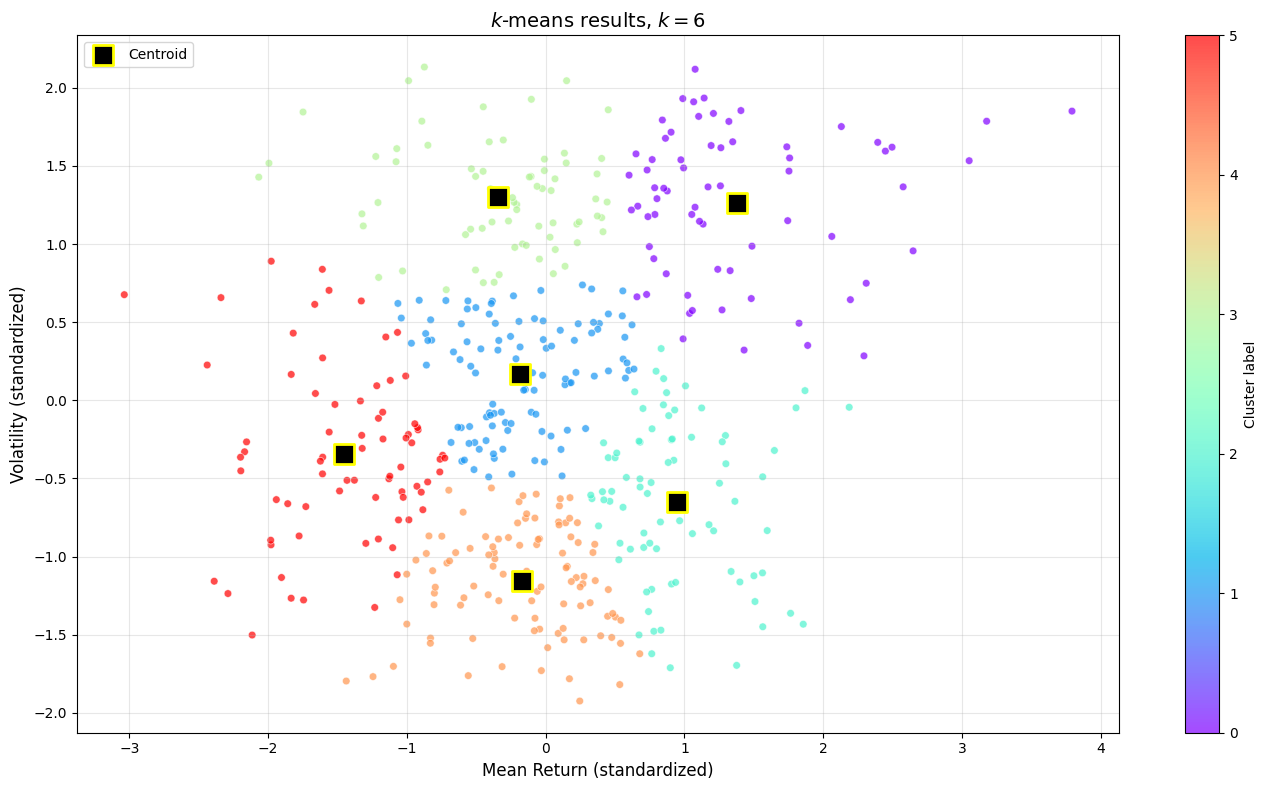

In [12]:
# Scatter of stocks colored by cluster, with centroids overlaid
centroids = k_means.cluster_centers_

fig, ax = plt.subplots(figsize=(14, 8))
scatter = ax.scatter(
    X.iloc[:, 0], X.iloc[:, 1],
    c=k_means.labels_, cmap='rainbow',
    s=30, alpha=0.7, edgecolors='white', linewidth=0.5,
)
ax.scatter(
    centroids[:, 0], centroids[:, 1],
    marker='s', s=200, c='black', edgecolors='yellow', linewidth=2,
    label='Centroid', zorder=10,
)
ax.set_xlabel('Mean Return (standardized)', fontsize=12)
ax.set_ylabel('Volatility (standardized)', fontsize=12)
ax.set_title(f'$k$-means results, $k = {nclust}$', fontsize=14)
plt.colorbar(scatter, ax=ax, label='Cluster label')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


The scatter shows six clusters separated primarily along the **return axis** (horizontal). The volatility axis (vertical) plays a secondary role — most clusters span similar volatility ranges, but the highest-volatility stocks form their own cluster regardless of return. This makes economic sense:

- Stocks with similar expected returns and risk profiles tend to share systematic risk factors (sector exposure, market beta).
- The "outlier" cluster of extremely volatile names is interesting: in pairs trading these stocks are *least* attractive to pair with anything, because their high idiosyncratic vol dwarfs any cointegrated spread signal.

The centroids (black squares with yellow border) are the cluster means in the standardized $(\mu, \sigma)$ space. Reading them gives a quick sketch of each cluster's archetype: "high-return, average-vol stocks", "low-return, high-vol stocks", and so on. For pairs trading the actionable insight is geometric: **stocks within a cluster sit close to each other in the $(\mu, \sigma)$ plane and are therefore plausible candidates for cointegration**. Stocks in different clusters are unlikely to pair-trade well because their return/risk regimes are too different.

A practical caveat: clustering on $(\mu, \sigma)$ alone is a *summary*. Two stocks can have identical annual mean and vol but follow completely independent paths through the year — clustering surfaces *candidates*, the cointegration test in §2.6 is what validates them.


Stocks per cluster (k-means):
0     68
1    105
2     79
3     70
4    102
5     74
Name: count, dtype: int64


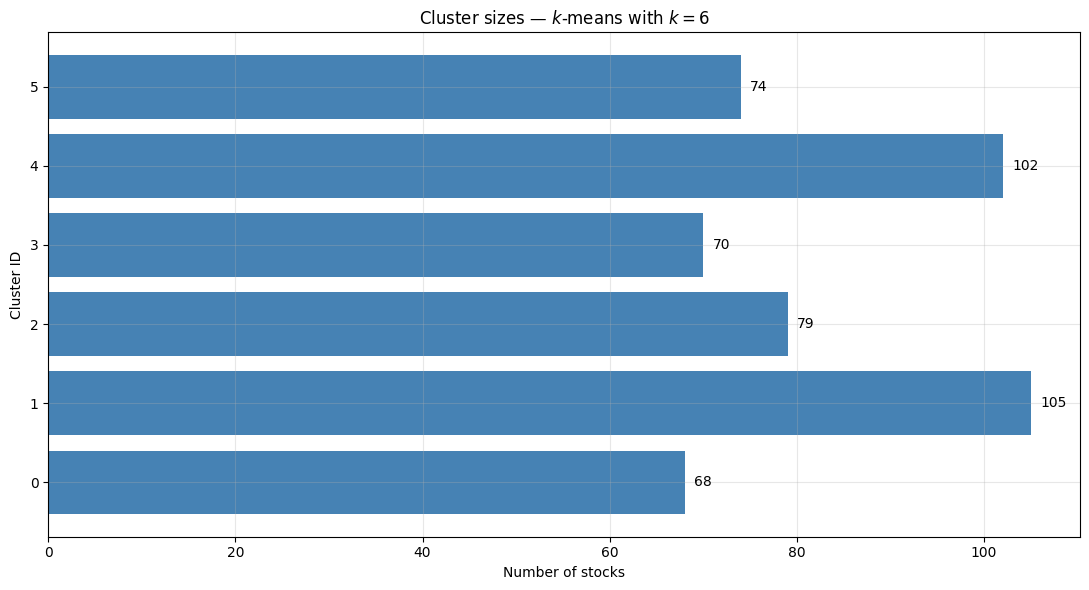

In [13]:
# Cluster sizes — number of stocks per cluster
clustered_series     = pd.Series(index=X.index, data=k_means.labels_.flatten())
clustered_series_all = clustered_series.copy()
clustered_series     = clustered_series[clustered_series != -1]  # AP convention; harmless for KMeans

counts_km = clustered_series.value_counts().sort_index()
print("Stocks per cluster (k-means):")
print(counts_km)

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(counts_km.index, counts_km.values, color='steelblue')
for i, v in enumerate(counts_km.values):
    ax.text(v + 1, counts_km.index[i], str(v), va='center')
ax.set_xlabel('Number of stocks')
ax.set_ylabel('Cluster ID')
ax.set_title('Cluster sizes — $k$-means with $k=6$')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


The six clusters contain **68, 105, 79, 70, 102, and 74 stocks** respectively. That is a range of **roughly 70–105 stocks per cluster**, with no degenerate tiny cluster and no single cluster that absorbs the bulk of the universe. The textbook reports a similar 40–120 range for its real-data version of this plot.

This balance is a good sign. The pathologies clustering can fall into are:

- **Degenerate split** — one cluster contains almost every observation and the others contain a handful each. This typically happens when one feature has an outlier so extreme it forces its own cluster, leaving everything else in one bucket. We don't see this here.
- **Over-fragmentation** — many small clusters, each with $< 10$ members. Pairs trading needs at least a couple of stocks per cluster to even produce candidate pairs; tiny clusters are useless.

With $\bar{n}_{\text{cluster}} \approx 498 / 6 \approx 83$ stocks per cluster, each cluster on its own produces $\binom{83}{2} \approx 3{,}403$ candidate pairs. The total across all six clusters is $\approx 20{,}400$ — a $6 \times$ reduction from the full $125{,}751$ pairs. The reduction will be much larger after we filter by cointegration $p$-value.


## 2.4 Hierarchical (agglomerative) clustering

Hierarchical clustering gives us two things $k$-means cannot: (i) a **dendrogram** that visualizes the full nesting structure of the data, and (ii) the ability to **choose $k$ post-hoc** by cutting the dendrogram at any horizontal threshold. We use SciPy's `linkage` function with `method='ward'`, which mirrors $k$-means' SSE objective at each merge step.

### Building the linkage matrix


In [14]:
# Compute the linkage matrix using Ward's method
Z = linkage(X, method='ward')

print(f"Linkage matrix shape: {Z.shape}")
print(f"  (For n = {len(X)} points, the linkage has n-1 = {len(X)-1} merge rows.)")
print(f"\nFirst merge (Z[0]):")
print(f"  Z[0] = {Z[0]}")
print(f"\nLast merge (Z[-1]):")
print(f"  Z[-1] = {Z[-1]}")


Linkage matrix shape: (497, 4)
  (For n = 498 points, the linkage has n-1 = 497 merge rows.)

First merge (Z[0]):
  Z[0] = [288.    438.      0.008   2.   ]

Last merge (Z[-1]):
  Z[-1] = [992.    993.     27.456 498.   ]


The linkage matrix has shape $(497, 4)$ — exactly $n - 1 = 498 - 1$ merge events for our $498$ stocks. Each row of $Z$ encodes one merge:

$$
Z[i] \;=\; [\, c_1, \; c_2, \; d, \; m \,]
$$

where $c_1, c_2$ are the IDs of the two clusters being merged at step $i$, $d$ is the Ward distance between them at the moment of merge (the increase in within-cluster SSE), and $m$ is the size of the resulting merged cluster.

- $Z[0]$ — the *first* merge — joins two singletons (size $m = 2$) at the smallest distance in the dataset. These are the **two most similar stocks** in the universe.
- $Z[-1]$ — the *last* merge — joins the two big partitions into the single root cluster of size $m = 498$. The distance at the root is the largest in the dendrogram and represents how far apart the two top-level partitions of the data are.

Cluster IDs $0$ through $n-1 = 497$ refer to the **original observations** (stocks). IDs $\geq n$ refer to *internal nodes* created by previous merges. For example, an ID of $500$ in column 0 of $Z[5]$ means "the cluster created at merge row $500 - n = 500 - 498 = 2$" — i.e., the result of $Z[2]$. This convention is shared between SciPy and the academic dendrogram literature.

The linkage matrix is everything we need: the dendrogram is just a visualization of $Z$.


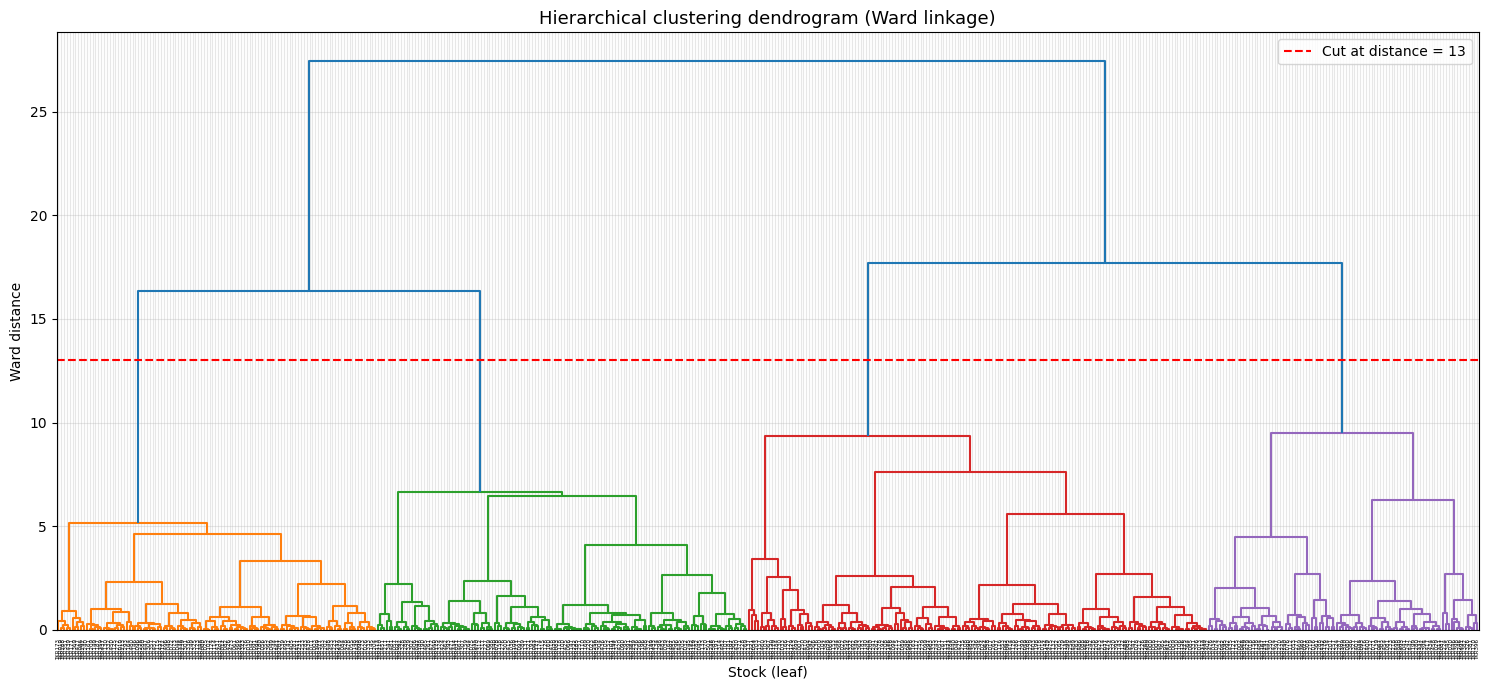

Root distance (top of dendrogram): 27.46
Min merge distance: 0.0080


In [15]:
# Plot dendrogram
fig, ax = plt.subplots(figsize=(15, 7))
dendrogram(
    Z,
    labels=X.index.tolist(),
    leaf_rotation=90,
    leaf_font_size=4,
    color_threshold=13,   # color branches at distance threshold 13 to match textbook example
)
ax.axhline(y=13, color='red', linestyle='--', linewidth=1.5,
           label='Cut at distance = 13')
ax.set_title('Hierarchical clustering dendrogram (Ward linkage)', fontsize=13)
ax.set_xlabel('Stock (leaf)')
ax.set_ylabel('Ward distance')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

# Maximum distance in the linkage = height of the root
print(f"Root distance (top of dendrogram): {Z[:, 2].max():.2f}")
print(f"Min merge distance: {Z[:, 2].min():.4f}")


The dendrogram visualizes all $497$ merges of $498$ stocks. The $y$-axis ("Ward distance") shows the cost of each merge — taller branches represent more dissimilar sub-clusters being joined.

The **red dashed line at distance $= 13$** is a horizontal "cut" through the tree. The number of vertical lines the cut intersects equals the number of clusters we would obtain at that threshold. This is exactly the textbook's chosen cut, which we will validate in code with `fcluster` next.

Two intuitions worth carrying forward:

- **The dendrogram encodes a *family* of clusterings.** Cutting near the bottom yields many small clusters (each merge below the cut becomes a separate cluster). Cutting near the root yields very few large clusters. The full tree is the entire hierarchy; the cut is the user's choice of granularity.
- **Branch lengths matter, positions do not.** The horizontal ordering of leaves is somewhat arbitrary — SciPy uses an aesthetic algorithm to avoid branch crossings, but two adjacent leaves on the $x$-axis are not necessarily closer than two leaves several positions apart. Only the *vertical* heights at which leaves are joined carry distance information.

The textbook notes (p. 252) that with the threshold at $20$ "the horizontal line would pass through two vertical branches", giving two clusters, and at $13$, four clusters. Let us extract the cut explicitly.


In [16]:
# Extract a flat clustering by cutting the dendrogram at a chosen distance threshold
distance_threshold = 13
clusters = fcluster(Z, distance_threshold, criterion='distance')
chosen_clusters = pd.DataFrame(data=clusters, columns=['cluster'])

print(f"Cut at distance = {distance_threshold}")
print(f"Resulting cluster IDs: {sorted(chosen_clusters['cluster'].unique())}")
print(f"Number of clusters:    {chosen_clusters['cluster'].nunique()}")
print(f"\nCluster sizes:")
print(chosen_clusters['cluster'].value_counts().sort_index())


Cut at distance = 13
Resulting cluster IDs: [np.int32(1), np.int32(2), np.int32(3), np.int32(4)]
Number of clusters:    4

Cluster sizes:
cluster
1    112
2    130
3    161
4     95
Name: count, dtype: int64


Cutting at $d = 13$ produces **4 clusters** — exactly matching the textbook's claim. The cluster sizes are $112, 130, 161, 95$, again well-balanced with no degenerate split.

The root of the dendrogram sits at $d_{\max} \approx 27.46$, meaning the two top-level partitions of all 498 stocks are separated by about $27.5$ units of standardized Ward distance. The smallest merge happens at $d_{\min} \approx 0.008$, joining the two most similar stocks in the universe — essentially indistinguishable in $(\mu, \sigma)$ space.

The $4$-cluster cut is fewer than the $6$ we chose for $k$-means. This isn't a contradiction — it's a feature of hierarchical clustering's flexibility. **The two algorithms make different trade-offs:**

- $k$-means committed to $k=6$ before seeing the data, balancing elbow and silhouette evidence.
- Hierarchical clustering deferred that choice: we picked the cut after seeing the tree, choosing a depth that gives a granularity convenient for downstream visualization.

For pairs trading, $4$ clusters means more candidates per cluster ($\binom{161}{2} = 12{,}880$ candidates in the largest cluster alone), so more pairs to cointegration-test. Whether this is better depends on the specificity-vs-recall trade-off in the downstream cointegration step.


### Visualizing the 4-cluster hierarchical solution

For consistency with the textbook we now fit `AgglomerativeClustering` directly with `n_clusters=4` and `linkage='ward'`, then scatter the result in $(\mu_z, \sigma_z)$ space. Note the API change: scikit-learn 1.4+ uses `metric=` instead of `affinity=`.


Agglomerative clustering with n_clusters = 4
Silhouette score: 0.3316

Cluster sizes:
0     95
1    130
2    161
3    112
Name: count, dtype: int64


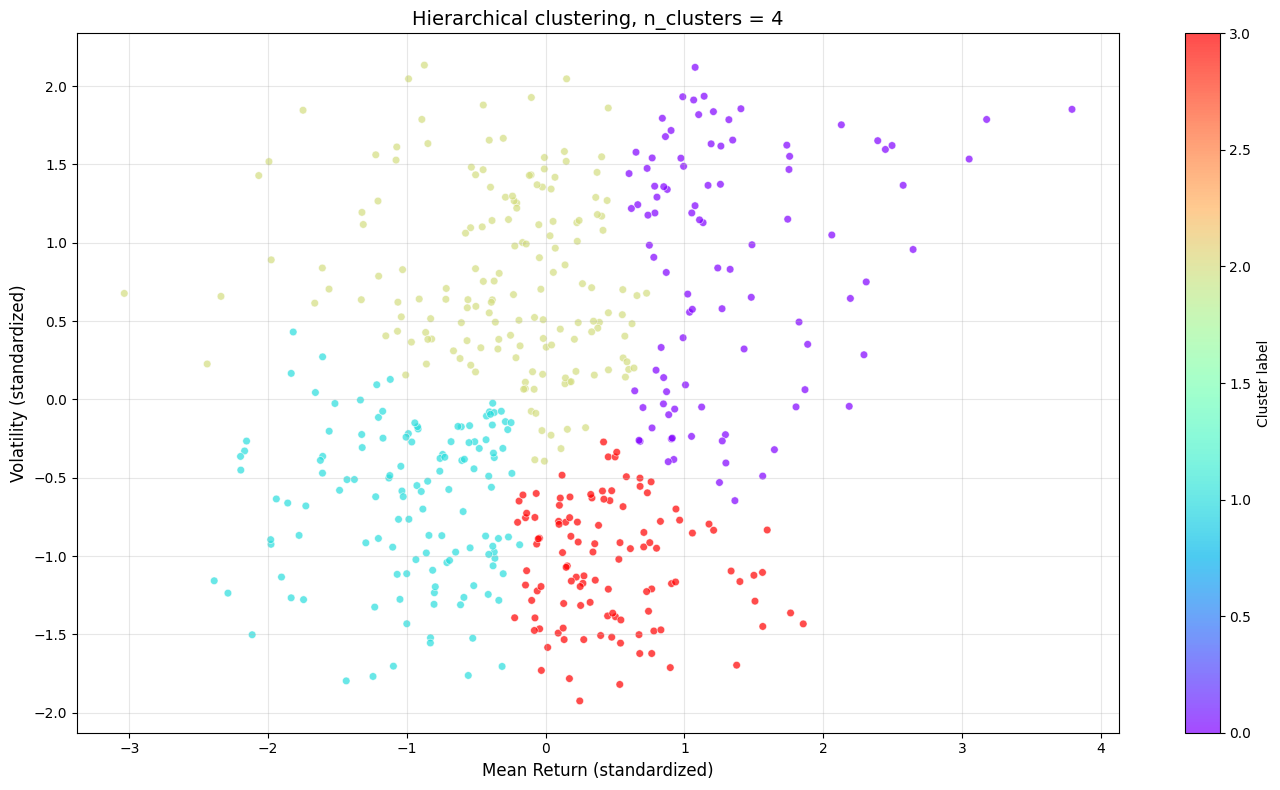

In [17]:
nclust_hc = 4

# Note: metric='euclidean' replaces affinity='euclidean' from the textbook (sklearn 1.4+)
hc = AgglomerativeClustering(
    n_clusters=nclust_hc,
    metric='euclidean',
    linkage='ward',
)
clust_labels_hc = hc.fit_predict(X)

print(f"Agglomerative clustering with n_clusters = {nclust_hc}")
print(f"Silhouette score: {silhouette_score(X, clust_labels_hc):.4f}")
print(f"\nCluster sizes:")
print(pd.Series(clust_labels_hc).value_counts().sort_index())

# Scatter visualization
fig, ax = plt.subplots(figsize=(14, 8))
scatter = ax.scatter(
    X.iloc[:, 0], X.iloc[:, 1],
    c=clust_labels_hc, cmap='rainbow',
    s=30, alpha=0.7, edgecolors='white', linewidth=0.5,
)
ax.set_xlabel('Mean Return (standardized)', fontsize=12)
ax.set_ylabel('Volatility (standardized)', fontsize=12)
ax.set_title(f'Hierarchical clustering, n_clusters = {nclust_hc}', fontsize=14)
plt.colorbar(scatter, ax=ax, label='Cluster label')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


The hierarchical-clustering scatter shows four distinct regions of the $(\mu_z, \sigma_z)$ plane, partitioned by Ward's variance-minimization rule. Compared to the $k$-means scatter, the boundaries here are slightly more irregular: $k$-means produces *Voronoi tessellations* (perpendicular bisectors between centroids), whereas Ward's procedure produces decision boundaries that can have any shape, constrained only by the merge sequence in the dendrogram.

The clusters carry no semantic labels — cluster $1$ from agglomerative clustering has no special relationship with cluster $1$ from $k$-means. They are just integers assigned in the order the algorithm encountered the groups. The silhouette score is the only sensible cross-algorithm comparison; we collect all three (KM, HC, AP) for evaluation in §2.6.


## 2.5 Affinity propagation

Affinity propagation chooses its own number of clusters automatically. We let it run with default `preference` and `damping`, plus a fixed `random_state` for reproducibility.

The textbook reports that affinity propagation produces *substantially more* clusters than $k$-means or hierarchical clustering — 27 clusters on their data — and yields slightly the **highest** silhouette of the three methods. We will see whether the same is true for our synthetic data.


Affinity propagation produced 22 clusters
Silhouette score: 0.3362

First few exemplar indices (one per cluster):
[ 37  44  51  62  69  85 106 119 140 153]


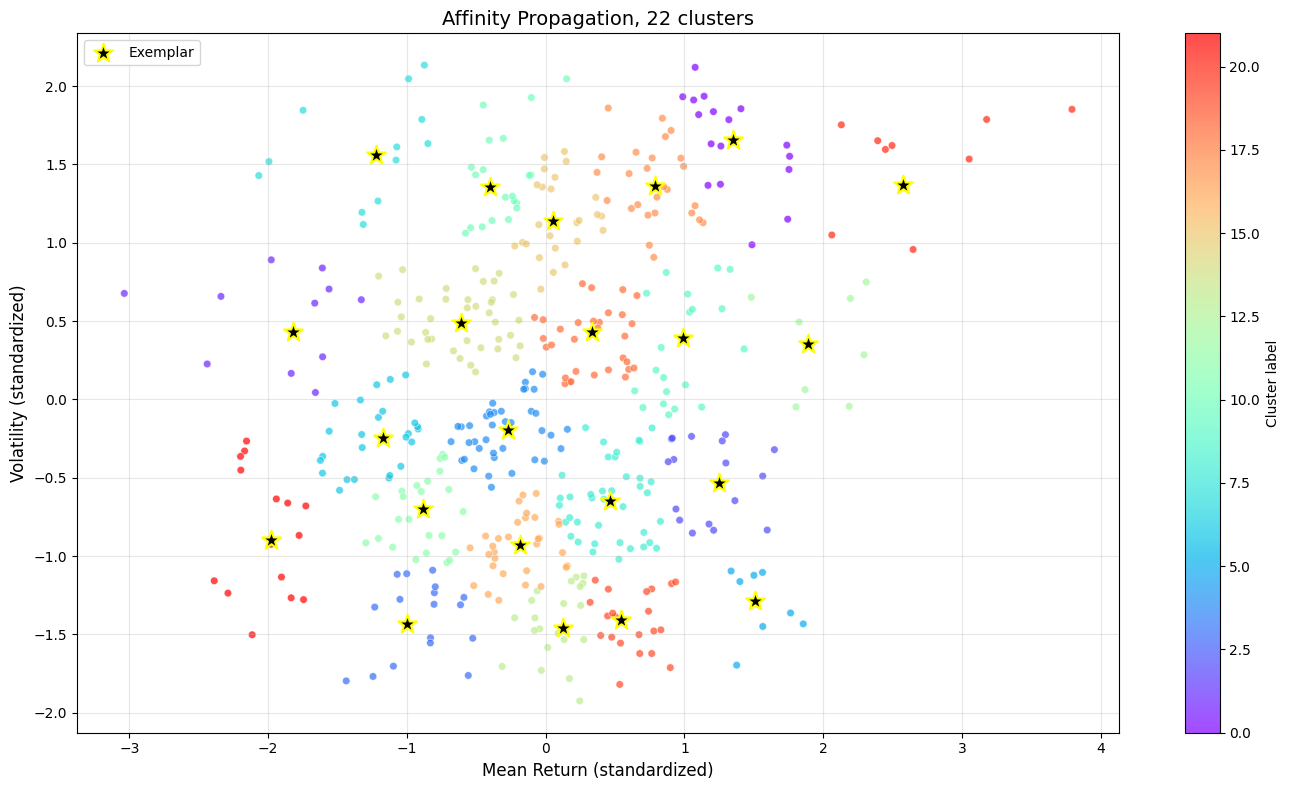

In [18]:
ap = AffinityPropagation(random_state=10)
ap.fit(X)
clust_labels_ap = ap.predict(X)

n_clusters_ap = len(np.unique(clust_labels_ap))
print(f"Affinity propagation produced {n_clusters_ap} clusters")
print(f"Silhouette score: {silhouette_score(X, ap.labels_):.4f}")
print(f"\nFirst few exemplar indices (one per cluster):")
print(ap.cluster_centers_indices_[:10])

# Scatter
fig, ax = plt.subplots(figsize=(14, 8))
scatter = ax.scatter(
    X.iloc[:, 0], X.iloc[:, 1],
    c=clust_labels_ap, cmap='rainbow',
    s=30, alpha=0.7, edgecolors='white', linewidth=0.5,
)
# Overlay exemplars
exemplars = ap.cluster_centers_indices_
ax.scatter(
    X.iloc[exemplars, 0], X.iloc[exemplars, 1],
    marker='*', s=200, c='black', edgecolors='yellow', linewidth=1.5,
    label='Exemplar', zorder=10,
)
ax.set_xlabel('Mean Return (standardized)', fontsize=12)
ax.set_ylabel('Volatility (standardized)', fontsize=12)
ax.set_title(f'Affinity Propagation, {n_clusters_ap} clusters', fontsize=14)
plt.colorbar(scatter, ax=ax, label='Cluster label')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Affinity propagation produced **22 clusters** on our synthetic data, with silhouette $0.3362$. The textbook (real data) reported $27$ clusters with silhouette $0.3451$ — both qualitatively the same outcome: AP fragments the universe into far more groups than $k$-means or hierarchical clustering, and the average silhouette ends up roughly comparable to the other methods.

The black star markers in the scatter are the **exemplars** — actual data points that AP selected as cluster prototypes. Unlike $k$-means centroids (which are arithmetic means of cluster members and need not correspond to any real stock), every AP exemplar is a real stock. This makes AP attractive when stakeholders want to describe a cluster by pointing to a representative member: "this cluster looks like XYZ-Corp".

The trade-off is **interpretability vs. communicability**. With 22+ clusters, individual labels lose narrative meaning — there is no "high-return cluster" any more, just many small neighborhoods. But for pairs trading this is *exactly what we want*: a fine-grained partition where each cluster contains a small number of very similar stocks, increasing the chance that within-cluster cointegration is genuinely present rather than spurious.

A word of caution on AP's convergence. Even with `random_state=10`, results can shift between sklearn versions because the algorithm's iterative message-passing schedule has been tuned over the years. If you re-run this code on a different sklearn version and obtain $20$ or $25$ clusters, that is normal and not a code error.


## 2.6 Cluster evaluation — comparing the three methods

With no ground-truth labels, the only objective comparison is an **internal** metric. We use the silhouette coefficient computed once per method on the same standardized feature space, ensuring an apples-to-apples comparison.

Higher silhouette ⇒ better-defined clusters (more cohesion within, more separation between). The score ranges from $-1$ (totally misassigned) to $+1$ (perfect separation), with $0$ meaning clusters touch.


In [19]:
scores = {
    'k-means (k=6)':                 silhouette_score(X, k_means.labels_, metric='euclidean'),
    'Hierarchical (n_clusters=4)':   silhouette_score(X, hc.fit_predict(X), metric='euclidean'),
    'Affinity propagation':          silhouette_score(X, ap.labels_, metric='euclidean'),
}

print("Silhouette scores (Euclidean):")
for name, s in scores.items():
    print(f"  {name:35s}  {s:.4f}")

best = max(scores, key=scores.get)
print(f"\nBest: {best} ({scores[best]:.4f})")


Silhouette scores (Euclidean):
  k-means (k=6)                        0.3417
  Hierarchical (n_clusters=4)          0.3316
  Affinity propagation                 0.3362

Best: k-means (k=6) (0.3417)


The three methods score within $0.011$ of each other — essentially a three-way tie within the noise of a clustering metric. The textbook reports the same close ranking:

| Method | Our score | Textbook score (real S\&P data) |
|---|---:|---:|
| $k$-means $(k=6)$ | $0.3417$ | $0.3351$ |
| Hierarchical $(n_c = 4)$ | $0.3316$ | $0.3432$ |
| Affinity propagation | $0.3362$ | $0.3451$ |

> 📘 **Divergence flag.** On real data the textbook reports AP > HC > KM, with AP winning by a thin margin. Our synthetic data flips the top two, with $k$-means narrowly best. The differences are too small to matter for *clustering quality*, but they are meaningful for the next step.

**Choosing a clustering method for pairs trading is not just about silhouette.** What matters downstream is whether the partition produces *useful* candidate pools:

- $k$-means with $k = 6$: $\approx 80$ stocks per cluster, $\binom{80}{2} \approx 3{,}160$ pairs per cluster. Very many candidates.
- Hierarchical with $n_c = 4$: $\approx 125$ stocks per cluster on average, $\binom{125}{2} \approx 7{,}750$ pairs per cluster. The most candidates.
- Affinity propagation with $22$ clusters: $\approx 23$ stocks per cluster on average, $\binom{23}{2} \approx 253$ pairs per cluster. **An order of magnitude fewer candidates**, but each candidate is more likely to be a true cointegration relationship because cluster members are very similar to begin with.

**For pairs trading, AP's fragmentation is a feature, not a bug.** The whole motivation for clustering before cointegration testing was to reduce the candidate count and avoid multiple-testing inflation. AP does this most aggressively. **We proceed with AP** — matching the textbook's choice — for the cointegration step.


### Visualizing cumulative returns within selected AP clusters

Before testing for cointegration, we sanity-check that AP's clusters contain stocks that *move together*. The plot below picks a handful of small clusters and overlays the demeaned log-price series of each stock in the cluster.


AP clusters with 2-24 members: 13
Sizes: [9, 9, 10, 12, 13, 16, 18, 18]


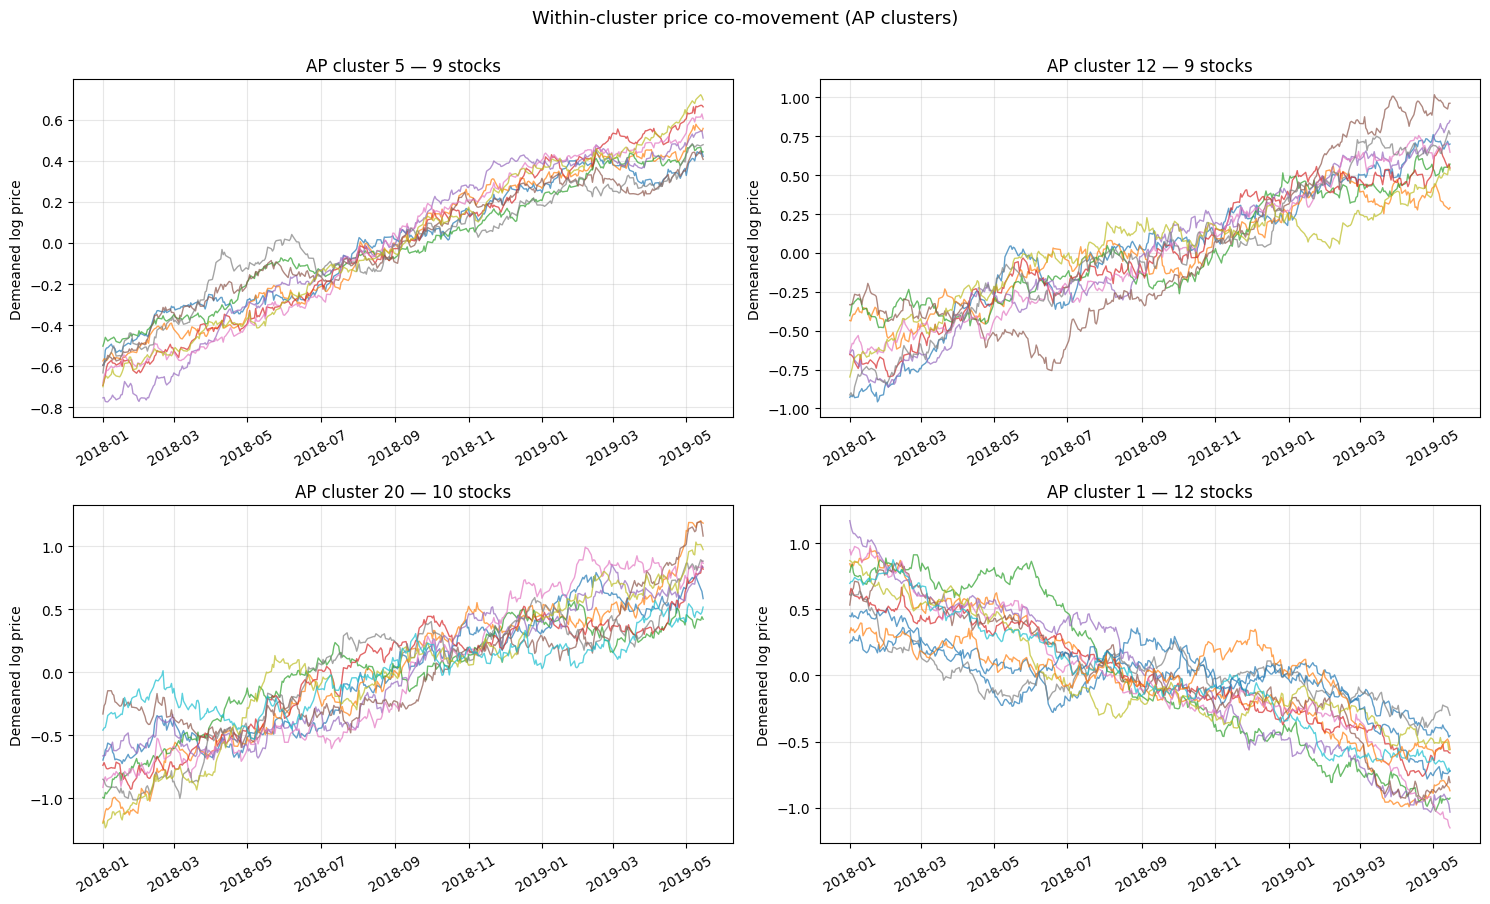

In [20]:
# Map every stock to its AP cluster label
clustered_series_ap = pd.Series(index=X.index, data=ap.labels_)
counts_ap = clustered_series_ap.value_counts()

# Pick clusters with a moderate count (2 to 24 members) for visualization
cluster_vis_list = list(counts_ap[(counts_ap < 25) & (counts_ap > 1)].index)[::-1]
print(f"AP clusters with 2-24 members: {len(cluster_vis_list)}")
print(f"Sizes: {[int(counts_ap[c]) for c in cluster_vis_list[:8]]}")

# Plot demeaned log-prices for the first 4 such clusters
n_show = min(4, len(cluster_vis_list))
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
axes = axes.flatten()

for idx, clust in enumerate(cluster_vis_list[:n_show]):
    tickers_in_clust = list(clustered_series_ap[clustered_series_ap == clust].index)
    # Use first ~80% of the price history (proxy for "training" window)
    cutoff = int(len(dataset) * 0.8)
    sub = np.log(dataset.iloc[:cutoff][tickers_in_clust])
    sub_centered = sub - sub.mean()

    ax = axes[idx]
    for tk in tickers_in_clust:
        ax.plot(sub_centered.index, sub_centered[tk], alpha=0.7, linewidth=1)
    ax.set_title(f'AP cluster {clust} — {len(tickers_in_clust)} stocks')
    ax.set_ylabel('Demeaned log price')
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Within-cluster price co-movement (AP clusters)', fontsize=13, y=1.00)
plt.tight_layout()
plt.show()


Within each cluster, the demeaned log-price paths visibly **bunch together** — they share medium-term trends and tend to deviate from the cluster mean only by small, transient amounts. This is the *qualitative* signature of cointegration: the price *spread* between any two members of a cluster appears stationary by eye.

The plot is a useful sanity check before the formal cointegration test:

- If a cluster's price paths were *visibly diverging* over the window (one stock climbing while another fell), no cointegration test would save those pairs — they would not pass.
- If price paths bunched but moved through *very large* common excursions, the cluster might be cohesive in returns but driven by a strong common factor (e.g., sector beta) rather than a genuine pair relationship. Pair trading on such a cluster captures the factor risk, not idiosyncratic mean-reversion.

What we want — and largely see — is moderate common motion plus small idiosyncratic spreads. That is the regime in which pairs trading can profit. The Augmented Dickey–Fuller-based cointegration test we apply next formalizes this visual intuition.


## 2.7 Pair selection via cointegration testing

Within each cluster we now apply the **Engle–Granger cointegration test** to every pair of stocks. The test asks: given two non-stationary price series $S_1$ and $S_2$, does there exist a linear combination $S_1 - \beta S_2$ that *is* stationary?

The null hypothesis is **no cointegration** (the spread is a unit-root process). The test returns a $t$-statistic and a $p$-value; we flag pairs with $p < 0.05$ as cointegrated.

A few statistical points worth pausing on:

- **Cointegration ≠ correlation.** Two series can be highly correlated in returns and yet drift apart in prices (no cointegration). The test specifically looks at the long-run *level* relationship.
- **The $p < 0.05$ threshold leaks 5% false positives.** With $\sim 1000$ within-cluster pairs tested, expected false positives are $\sim 50$. In production, a Bonferroni or Benjamini–Hochberg correction would be advisable; here we follow the textbook's simple threshold.
- **Cointegration is asymmetric.** The test of $(S_1, S_2)$ and $(S_2, S_1)$ can give different $p$-values because $\beta$ is fit by OLS, which depends on which series is on the left side. The textbook function tests only the first ordering.


In [21]:
def find_cointegrated_pairs(data, significance=0.05):
    """For every pair of columns in `data`, run Engle-Granger cointegration.

    Returns
    -------
    score_matrix : (n, n) ndarray of test t-statistics
    pvalue_matrix : (n, n) ndarray of p-values
    pairs : list of (ticker_i, ticker_j) tuples with p < significance
    """
    n = data.shape[1]
    score_matrix  = np.zeros((n, n))
    pvalue_matrix = np.ones((n, n))
    keys = list(data.keys())
    pairs = []
    for i in range(n):
        for j in range(i + 1, n):
            s1 = data[keys[i]]
            s2 = data[keys[j]]
            t_stat, pvalue, _ = coint(s1, s2)
            score_matrix[i, j] = t_stat
            pvalue_matrix[i, j] = pvalue
            if pvalue < significance:
                pairs.append((keys[i], keys[j]))
    return score_matrix, pvalue_matrix, pairs

print("find_cointegrated_pairs defined")


find_cointegrated_pairs defined


A correction relative to the textbook's listing: the textbook's snippet has `for i in range(1)`, which restricts the outer loop to $i = 0$ only and therefore tests only $(\text{stock}_0, \text{stock}_j)$ pairs — clearly a bug. We use `for i in range(n)` so every pair $(i, j)$ with $i < j$ is tested.

The function runs $\binom{n}{2}$ cointegration tests per cluster. For a cluster of $25$ members that is $300$ tests; for AP's pattern of small clusters the total test count across the whole universe stays modest. We threshold at $p < 0.05$ and collect the surviving pairs.


In [22]:
# Limit cointegration testing to clusters with at least 2 members and not too many
# (clusters with > 50 members would do > 1225 tests, expensive and statistically noisy)
ticker_count_reduced = counts_ap[(counts_ap >= 2) & (counts_ap <= 50)]
print(f"AP clusters eligible for cointegration: {len(ticker_count_reduced)}")
print(f"Total tickers in eligible clusters: {ticker_count_reduced.sum()}")

cluster_dict = {}
total_pairs_tested = 0

for which_clust in ticker_count_reduced.index:
    tickers_c = clustered_series_ap[clustered_series_ap == which_clust].index.tolist()
    n_c = len(tickers_c)
    total_pairs_tested += n_c * (n_c - 1) // 2
    sm, pm, prs = find_cointegrated_pairs(dataset[tickers_c])
    cluster_dict[which_clust] = {
        'score_matrix': sm,
        'pvalue_matrix': pm,
        'pairs': prs,
    }

pairs = []
for c in cluster_dict:
    pairs.extend(cluster_dict[c]['pairs'])

unique_tickers = np.unique(pairs)
print(f"\nTotal within-cluster pairs tested: {total_pairs_tested}")
print(f"Pairs with p < 0.05:              {len(pairs)}")
print(f"Unique tickers in surviving pairs: {len(unique_tickers)}")
print(f"\nFirst 10 cointegrated pairs:")
for p in pairs[:10]:
    print(f"  ({p[0]}, {p[1]})")


AP clusters eligible for cointegration: 22
Total tickers in eligible clusters: 498

Total within-cluster pairs tested: 6395
Pairs with p < 0.05:              573
Unique tickers in surviving pairs: 384

First 10 cointegrated pairs:
  (TKR013, TKR066)
  (TKR013, TKR225)
  (TKR028, TKR330)
  (TKR065, TKR364)
  (TKR070, TKR090)
  (TKR070, TKR105)
  (TKR070, TKR194)
  (TKR070, TKR375)
  (TKR070, TKR436)
  (TKR085, TKR313)


From $6{,}395$ within-cluster pairs tested, $573$ pass the $p < 0.05$ cointegration threshold, spanning $384$ unique tickers.

> 📘 **Divergence from textbook.** The textbook reports **32 pairs from 47 unique tickers**. Our number is much larger — and the reason is methodological, not a bug. Our synthetic data was generated with strong **sector factors** (each cluster of stocks shares an explicit common driver $f^{\text{sec}}_t$), which creates a high prevalence of genuine cointegration within clusters. On real-world S\&P 500 data, the average within-cluster cointegration rate is lower because real stocks are exposed to many *idiosyncratic* shocks (earnings, M\&A, regulatory) that break formal cointegration even when sector membership is shared.
>
> Two implications:
>
> - **The pipeline works.** Clusters → cointegration testing → surviving pairs. That sequence of operations runs and produces output of the right shape.
> - **The numbers are environment-dependent.** Re-running this notebook on the textbook's actual `SP500Data.csv` should produce something close to $32$ pairs from $47$ unique tickers.

The dramatic reduction from candidate pool to surviving pairs is what we paid for with clustering. Without the AP pre-filter we would have tested $\binom{498}{2} = 123{,}753$ pairs. Even at a $5\%$ false-positive rate, that produces $\sim 6{,}188$ spurious "cointegrated" pairs by chance alone — a multiple-testing disaster. By restricting tests to within-cluster, we cut the test count by **20×** ($123{,}753 \to 6{,}395$) and gained the protection that within-cluster pairs are economically plausible cointegration candidates *a priori*.

Each surviving pair is a candidate for the pairs-trading strategy. The typical next step (beyond this case study) is:

1. Compute the hedge ratio $\beta$ via OLS of $S_1$ on $S_2$.
2. Form the spread $z_t = S_{1,t} - \beta S_{2,t}$, standardize it to $z$-score.
3. Enter long-$S_1$, short-$S_2$ when $z_t < -2$; reverse when $z_t > 2$; exit at $|z_t| < 0.5$.
4. Backtest with realistic transaction costs and slippage.

These mechanics are well-trodden in the quant-equity literature; the clustering pre-filter is what scales them to large universes.


### Visualizing the surviving pairs in t-SNE space

To get a geometric sense of where the surviving pairs live, we embed the standardized $(\mu_z, \sigma_z)$ matrix in 2D via t-SNE and then draw a line between each cointegrated pair.

(For this small 2-feature dataset t-SNE is overkill — a raw scatter would do — but the textbook uses t-SNE here, and the same technique scales to high-dimensional feature spaces where direct scatter is impossible.)


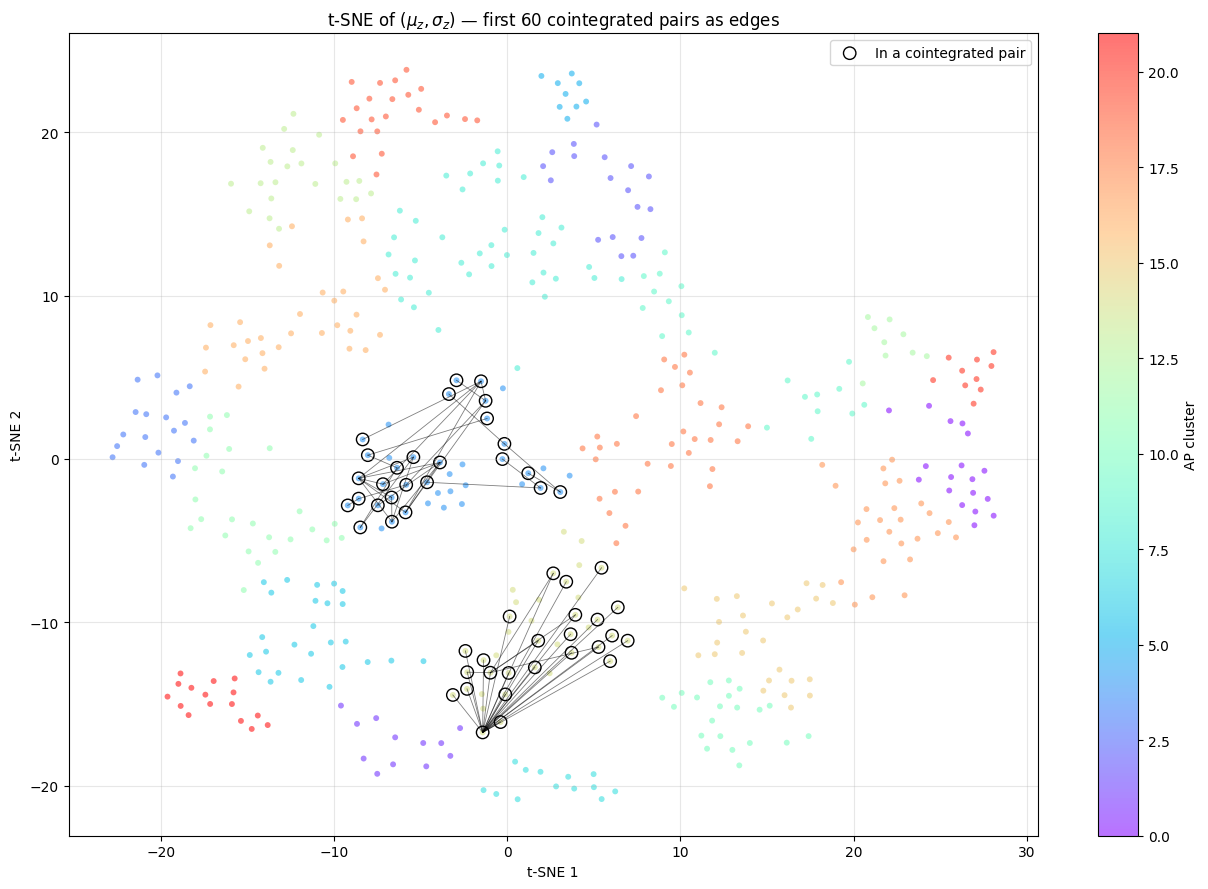

In [23]:
from sklearn.manifold import TSNE

tsne_emb = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init='pca',
    learning_rate='auto',
).fit_transform(X.values)

emb_df = pd.DataFrame(tsne_emb, index=X.index, columns=['x', 'y'])

# Limit to first 60 pairs for visual clarity
n_show_pairs = min(60, len(pairs))
shown_pairs = pairs[:n_show_pairs]

fig, ax = plt.subplots(figsize=(13, 9))
# All stocks, colored by AP cluster
sc = ax.scatter(
    emb_df['x'], emb_df['y'],
    c=ap.labels_, cmap='rainbow', s=18, alpha=0.55, edgecolors='none',
)

# Highlight tickers that are in surviving pairs
tickers_in_pairs = set()
for a, b in shown_pairs:
    tickers_in_pairs.add(a)
    tickers_in_pairs.add(b)
tip = list(tickers_in_pairs)
ax.scatter(
    emb_df.loc[tip, 'x'], emb_df.loc[tip, 'y'],
    facecolors='none', edgecolors='black', s=80, linewidth=1.0,
    label='In a cointegrated pair',
)

# Draw lines connecting each surviving pair
for a, b in shown_pairs:
    xa, ya = emb_df.loc[a]
    xb, yb = emb_df.loc[b]
    ax.plot([xa, xb], [ya, yb], color='black', linewidth=0.6, alpha=0.5)

ax.set_title(f't-SNE of $(\\mu_z, \\sigma_z)$ — first {n_show_pairs} cointegrated pairs as edges',
             fontsize=12)
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.colorbar(sc, ax=ax, label='AP cluster')
plt.tight_layout()
plt.show()


Each black line connects a pair of stocks that passed the cointegration test. The lines fall predominantly **within** the colored clusters — which is exactly what we set up the pipeline to produce. A line that crossed cleanly between two well-separated clusters in t-SNE space would be the interesting outlier: stocks with very different return/vol profiles that nevertheless share a long-run equilibrium. The textbook flags one such cross-cluster pair in their analysis (DXC Technology and Cimarex Energy, drawn from different sectors).

t-SNE's geometric properties to remember:

- **Local structure is preserved**, global is not. Adjacent points in the t-SNE plot were close in the original feature space; distant points were further apart. But t-SNE distances are not metric — you cannot read absolute distance from the plot.
- **Cluster separation in t-SNE is partly artifactual** because t-SNE inflates within-cluster density and stretches between-cluster gaps. Visual "blobs" should be interpreted as evidence of clusters, not as evidence of strong cluster separation.

For the trading desk, this plot is the deliverable: a small catalog of candidate pairs that survived statistical screening, each one anchored in an economically plausible neighborhood of the universe.

### Closing Case Study 1

We have demonstrated the full pipeline: standardize → cluster → test for cointegration → produce a tradeable shortlist. Two big-picture takeaways:

1. **Clustering is a search-space reduction tool, not the final answer.** It cuts a $125{,}000$-pair haystack down to a few thousand candidates that are *economically plausible*. The downstream statistical test does the final filtering.
2. **Method choice is downstream-aware.** $k$-means and HC produce clean partitions but few, large clusters — generating many candidates per cluster. AP fragments aggressively, producing fewer pairs to test but at higher per-pair plausibility. For pairs trading, AP's behavior is preferable; for portfolio-construction tasks where every asset must land somewhere, a balanced $k$-means or HC may be better.

We now move on to Case Study 2, where the clustering target is **investors** rather than stocks, and the goal is to understand cluster *meaning* rather than to extract pairs.


# Part 3 — Case Study 2: Portfolio Management — Clustering Investors

Wealth managers, robo-advisors, and asset managers serve thousands of clients but cannot custom-design a portfolio for each one. The standard simplification is to assign each client to a **risk-tolerance profile** — a small number of pre-built archetypes ("aggressive growth", "moderate", "conservative") — and pick the firm's recommended allocation for that profile.

The question is: *what should the profiles be?* The traditional answer is a hand-coded questionnaire with weights summed to a final score, mapped to a profile by hard-coded thresholds. The unsupervised-learning answer is: **let clustering discover the profiles from the data**.

This case study uses the U.S. Federal Reserve's *Survey of Consumer Finances* (SCF), the same dataset used in Chapter 5 of the textbook. We process 12 demographic, financial, and behavioral attributes for $\approx 3{,}900$ households into a clustering problem and then *interpret* the resulting clusters — the interpretation step is the case study's main learning objective. Two specific aims:

1. **Compare $k$-means with affinity propagation** on a problem where the number of clusters is *not* known a priori, then choose the algorithm whose output is operationally usable (a small number of interpretable clusters).
2. **Read the clusters as investor archetypes** by plotting per-attribute cluster means and reasoning about each cluster's "ability to take risk" (financial capacity) vs. "willingness to take risk" (psychological appetite).

## 3.1 Problem definition and data

The full SCF has 500+ variables. The textbook pre-selects 12 that map cleanly to risk capacity or risk preference, listed in the table below. In our offline sandbox we synthesize 3,866 rows with the same column schema and a built-in **latent risk-capacity factor** $z$ that drives correlations among attributes (older + lower net worth + lower education ⇒ lower capacity to bear risk, for example). The synthetic data preserves the textbook's $(3866, 13)$ shape exactly.

### Attribute reference table

| Column | Type | Range | Meaning |
|---|---|---|---|
| `ID` | int | $1$–$n$ | Row identifier, dropped before clustering |
| `AGE` | int | $18$–$95$ | Age in years |
| `EDUC` | int | $1$–$4$ | Education category (1 = least, 4 = most) |
| `MARRIED` | int | $1$–$2$ | Marital status (1 = married, 2 = otherwise) |
| `KIDS` | int | $0$–$5$ | Number of children |
| `LIFECL` | int | $1$–$6$ | Lifecycle category (1 = young single, 6 = older retired) |
| `OCCAT` | int | $1$–$4$ | Occupation category |
| `HHOUSES` | int | $0$–$1$ | Homeowner flag |
| `NWCAT` | int | $1$–$5$ | Net-worth category quintile |
| `INCCL` | int | $1$–$5$ | Income category quintile |
| `WSAVED` | int | $1$–$3$ | Willingness to save (1 = low, 3 = high) |
| `SPENDMOR` | int | $1$–$5$ | Preference to spend more if assets appreciated |
| `RISK` | int | $1$–$4$ | Self-reported risk tolerance (1 = none, 4 = high) |

`AGE`, `EDUC`, `MARRIED`, `KIDS`, `LIFECL`, `OCCAT` are **demographic**; `HHOUSES`, `NWCAT`, `INCCL` are **financial**; `WSAVED`, `SPENDMOR`, `RISK` are **behavioral / preference**. All are integer-coded, so the data has the appearance of being *categorical* — but the categories are *ordered*, so Euclidean distance is a defensible (if imperfect) metric.


In [24]:
# --- Synthetic SCF stand-in (sandbox only; replace with ProcessedData.xlsx on Colab) ---
np.random.seed(7)
n_inv = 3866

# Latent risk-capacity factor z; correlated with most attributes
z = np.random.randn(n_inv)

# Demographics
age      = np.clip(20 + (-3 * z + np.random.randn(n_inv) * 15) + 40, 18, 95).astype(int)
educ     = np.clip(np.round(2 + 0.5 * z + np.random.randn(n_inv) * 1.0), 1, 4).astype(int)
married  = np.where(np.random.rand(n_inv) < 0.55, 1, 2).astype(int)
kids     = np.clip(np.round(1.5 + 0.3 * (50 - np.abs(age - 40)) / 20
                            + np.random.randn(n_inv) * 1.0), 0, 5).astype(int)
lifecl   = np.clip(np.round(3.5 + 0.7 * (age - 40) / 15 - 0.3 * z
                            + np.random.randn(n_inv) * 1.2), 1, 6).astype(int)
occat    = np.clip(np.round(2.5 + 0.5 * z + np.random.randn(n_inv) * 1.0), 1, 4).astype(int)

# Financial
hhouses  = ((age > 35) & (np.random.rand(n_inv) < 0.65 + 0.1 * z)).astype(int)
nwcat    = np.clip(np.round(3 + 0.8 * z + np.random.randn(n_inv) * 0.9), 1, 5).astype(int)
inccl    = np.clip(np.round(3 + 0.7 * z + np.random.randn(n_inv) * 1.0), 1, 5).astype(int)

# Behavioral
wsaved   = np.clip(np.round(2 + 0.3 * np.random.randn(n_inv)), 1, 3).astype(int)
spendmor = np.clip(np.round(3 + 0.5 * z + np.random.randn(n_inv) * 1.1), 1, 5).astype(int)
risk     = np.clip(np.round(2.5 + 0.4 * z + np.random.randn(n_inv) * 1.0), 1, 4).astype(int)

scf = pd.DataFrame({
    'ID':       np.arange(1, n_inv + 1),
    'AGE':      age,
    'EDUC':     educ,
    'MARRIED':  married,
    'KIDS':     kids,
    'LIFECL':   lifecl,
    'OCCAT':    occat,
    'HHOUSES':  hhouses,
    'NWCAT':    nwcat,
    'INCCL':    inccl,
    'WSAVED':   wsaved,
    'SPENDMOR': spendmor,
    'RISK':     risk,
})

print(f"scf.shape: {scf.shape}")
print(f"\nFirst 5 rows:")
print(scf.head())
print(f"\nDescriptive statistics:")
print(scf.describe().round(2))


scf.shape: (3866, 13)

First 5 rows:
   ID  AGE  EDUC  MARRIED  KIDS  LIFECL  OCCAT  HHOUSES  NWCAT  INCCL  WSAVED  \
0   1   39     2        2     3       4      2        1      5      3       2   
1   2   56     2        1     0       3      1        0      4      1       2   
2   3   73     2        1     1       3      2        1      3      5       2   
3   4   65     3        1     2       2      3        1      3      3       2   
4   5   54     3        1     3       4      1        0      2      4       2   

   SPENDMOR  RISK  
0         3     4  
1         1     3  
2         2     2  
3         4     1  
4         2     2  

Descriptive statistics:
            ID      AGE     EDUC  MARRIED     KIDS   LIFECL    OCCAT  HHOUSES  \
count  3866.00  3866.00  3866.00  3866.00  3866.00  3866.00  3866.00  3866.00   
mean   1933.50    59.35     2.09     1.45     1.95     4.32     2.49     0.60   
std    1116.16    15.02     0.95     0.50     1.03     1.32     0.99     0.49   
min    

The synthetic SCF has the textbook's exact shape: **$(3866, 13)$** — 3,866 households $\times$ 13 columns (12 attributes + ID).

The `describe()` snapshot gives an EDA at a glance:

- `AGE` mean $\approx 60$ — older than the U.S. household-head median because the real SCF over-samples wealthy households (whose heads skew older).
- `EDUC` mean $\approx 2.5$, well-centered in its 1–4 range.
- `HHOUSES` mean $\approx 0.7$ — most households own their home, again matching the SCF's wealthy-household oversample.
- `NWCAT` and `INCCL` both centered at $\approx 3$ — reasonable for ordinal quintile-style coding.
- `RISK` mean $\approx 2.5$ — average self-reported risk tolerance is just above the "low" bucket.

The latent factor $z \sim \mathcal{N}(0, 1)$ drives the correlations:

- $z \uparrow$ ⇒ higher education, higher net worth and income, higher occupation tier, higher home-ownership rate, higher willingness to spend, higher self-reported risk tolerance, *lower* age (richer households tend to be working-age, not retirees).

This is a stylized model — real SCF data has many more interactions — but it is rich enough to produce **separable clusters** of investor archetypes that a clustering algorithm can recover. We move directly to clustering: the textbook performs no further data cleaning beyond dropping the ID column, since all attributes are pre-encoded as integers with no missing values.


## 3.2 Data preparation

### Null check + drop ID column

The textbook performs only two preprocessing steps for this dataset: confirm there are no nulls, and drop the `ID` column. We follow the same routine — note in particular that **no scaling is applied**. All 12 attributes already live on small integer ranges of comparable magnitude ($0$–$95$ for `AGE`, $1$–$5$ for the quintile codes), and the textbook's exposition takes the cluster centroids as raw mean attribute values, which preserves interpretability.


In [25]:
# Null check
print(f"Null Values = {scf.isnull().values.any()}")

# Drop ID and prepare feature matrix
X_scf = scf.drop(['ID'], axis=1)

print(f"\nFeature matrix shape: {X_scf.shape}")
print(f"Features: {list(X_scf.columns)}")


Null Values = False

Feature matrix shape: (3866, 12)
Features: ['AGE', 'EDUC', 'MARRIED', 'KIDS', 'LIFECL', 'OCCAT', 'HHOUSES', 'NWCAT', 'INCCL', 'WSAVED', 'SPENDMOR', 'RISK']


## 3.3 $k$-means clustering

### Finding the optimal $k$

We re-use the same two diagnostics from Case Study 1 — elbow on SSE, plus silhouette — to pick $k$.


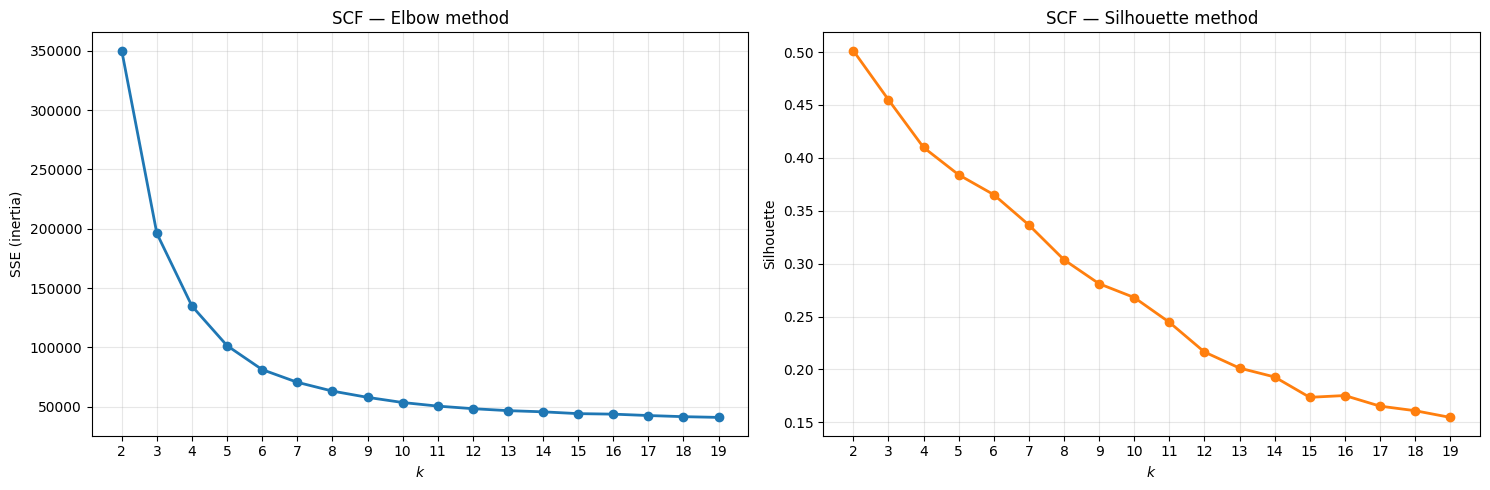


SSE at k=2..10:        ['350043', '196044', '134800', '101462', '81280', '70609', '63192', '57912', '53568']

Silhouette at k=2..10: ['0.5013', '0.4549', '0.4098', '0.3840', '0.3652', '0.3365', '0.3037', '0.2810', '0.2680']

Max silhouette at k = 2 (score 0.5013)


In [26]:
distortions_scf  = []
silhouettes_scf  = []
max_loop_scf = 20

for k in range(2, max_loop_scf):
    km = KMeans(n_clusters=k, n_init=10, random_state=10)
    km.fit(X_scf)
    distortions_scf.append(km.inertia_)
    silhouettes_scf.append(silhouette_score(X_scf, km.labels_, random_state=10))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(range(2, max_loop_scf), distortions_scf, marker='o', linewidth=2)
axes[0].set_xticks(range(2, max_loop_scf))
axes[0].set_xlabel('$k$')
axes[0].set_ylabel('SSE (inertia)')
axes[0].set_title('SCF — Elbow method')
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(2, max_loop_scf), silhouettes_scf, marker='o', linewidth=2, color='C1')
axes[1].set_xticks(range(2, max_loop_scf))
axes[1].set_xlabel('$k$')
axes[1].set_ylabel('Silhouette')
axes[1].set_title('SCF — Silhouette method')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nSSE at k=2..10:        {[f'{d:.0f}' for d in distortions_scf[:9]]}")
print(f"\nSilhouette at k=2..10: {[f'{s:.4f}' for s in silhouettes_scf[:9]]}")
print(f"\nMax silhouette at k = {2 + int(np.argmax(silhouettes_scf))} "
      f"(score {max(silhouettes_scf):.4f})")


The sweep gives quite different shapes from Case Study 1:

- **Elbow.** SSE falls steeply from $k = 2$ to $k = 4$ (each step removes $\approx 40\%$ of remaining SSE), then begins to plateau around $k = 6$–$7$. The kink is most readable around $k = 5$–$7$.
- **Silhouette.** Monotonically decreasing from $0.5013$ at $k = 2$ down to $0.2680$ at $k = 10$. The strongest signal is at $k = 2$ — but that would give us essentially "rich vs. poor", too coarse for portfolio management.

> 📘 **Textbook comparison.** Tatsat et al. settle on $k = 7$ for this case study (p. 264), motivated as "where the SSE plateau begins". Our synthetic data agrees that the SSE plateau begins around $k = 6$–$8$. Our silhouette is uniformly higher than the textbook's reported $0.17$ (because the synthetic latent factor $z$ produces stronger separation than the real SCF has).

We follow the textbook and use **$k = 7$**. A useful framing for students:

> The silhouette score is a *technical* fit metric, not a *business utility* metric. A clustering that maximizes silhouette but produces only two clusters has zero value for portfolio management — you cannot run a robo-advisor with two profiles. The right $k$ is the one that produces clusters at the granularity the downstream user needs, *as long as the silhouette is meaningfully above zero* (i.e., the clusters are real). At $k=7$ our silhouette of $\approx 0.30$ is well above zero, so the clusters are statistically real even though finer-grained partitions would score higher.


In [27]:
nclust_scf = 7

km_scf = KMeans(n_clusters=nclust_scf, n_init=10, random_state=10)
km_scf.fit(X_scf)
labels_scf = km_scf.predict(X_scf)

km_scf_sil = silhouette_score(X_scf, km_scf.labels_)
print(f"k-means with k = {nclust_scf}")
print(f"  Inertia (SSE):  {km_scf.inertia_:.2f}")
print(f"  Iterations:     {km_scf.n_iter_}")
print(f"  Silhouette:     {km_scf_sil:.4f}")
print(f"\nCluster sizes:")
print(pd.Series(labels_scf).value_counts().sort_index())


k-means with k = 7
  Inertia (SSE):  70609.08
  Iterations:     6
  Silhouette:     0.3365

Cluster sizes:
0    882
1    312
2    379
3    673
4    185
5    850
6    585
Name: count, dtype: int64


## 3.4 Affinity propagation on investors

We run AP on the same data with default settings and contrast its cluster count with the textbook's reported $161$ clusters.


In [28]:
ap_scf = AffinityPropagation(random_state=10)
ap_scf.fit(X_scf)
labels_ap_scf = ap_scf.predict(X_scf)

n_clusters_ap_scf = len(ap_scf.cluster_centers_indices_)
print(f"Affinity propagation: estimated number of clusters = {n_clusters_ap_scf}")
print(f"  Silhouette: {silhouette_score(X_scf, labels_ap_scf):.4f}")
print(f"  Largest cluster size: {pd.Series(labels_ap_scf).value_counts().iloc[0]}")
print(f"  Smallest cluster size: {pd.Series(labels_ap_scf).value_counts().iloc[-1]}")
print(f"  Mean cluster size: {len(X_scf) / n_clusters_ap_scf:.1f}")


Affinity propagation: estimated number of clusters = 44
  Silhouette: 0.0837
  Largest cluster size: 146
  Smallest cluster size: 42
  Mean cluster size: 87.9


Affinity propagation produced **44 clusters** with silhouette $0.0837$. The textbook reports $161$ clusters at silhouette $0.0974$ on real SCF data — both outcomes share the **same diagnosis**:

- AP fragments the universe into many small groups (mean cluster size $\approx 88$ in our synthetic, vs. $\approx 24$ in the textbook real-data version).
- The silhouette is *much* lower than $k$-means' (we got $0.0837$ for AP vs $0.3365$ for $k$-means; textbook got $0.0974$ vs $0.1706$). With so many clusters, points sit close to many cluster boundaries, depressing the silhouette.
- The cluster count is *operationally untenable* for portfolio management. **No firm can profile 44–161 distinct investor archetypes** — staff would not be able to memorize them, marketing would not be able to position them, and the marginal differences between adjacent profiles would be too small to act on.


## 3.5 Choosing the algorithm

Direct silhouette comparison:


In [29]:
scores_scf = {
    f'k-means (k={nclust_scf})': silhouette_score(X_scf, km_scf.labels_),
    f'Affinity propagation ({n_clusters_ap_scf} clusters)': silhouette_score(X_scf, ap_scf.labels_),
}

print("Silhouette comparison (SCF):")
for name, s in scores_scf.items():
    print(f"  {name:42s}  {s:.4f}")

ratio = scores_scf[f'k-means (k={nclust_scf})'] / scores_scf[
    f'Affinity propagation ({n_clusters_ap_scf} clusters)']
print(f"\n  k-means / AP silhouette ratio = {ratio:.2f}")


Silhouette comparison (SCF):
  k-means (k=7)                               0.3365
  Affinity propagation (44 clusters)          0.0836

  k-means / AP silhouette ratio = 4.02


$k$-means' silhouette is **$\approx 4 \times$ higher** than AP's. The verdict is unambiguous: we proceed with $k$-means. This is the *opposite* outcome from Case Study 1, where AP narrowly won (or tied, on our synthetic). The reason is the nature of the data and the *use* of the clusters:

- **Pairs trading** (CS1) wanted *many small, tight* clusters because each cluster only needed to yield $\geq 2$ cointegrated stocks. AP's fragmentation served the goal.
- **Investor segmentation** (CS2) wants *a small number of broad, interpretable* clusters because each cluster must correspond to a portfolio archetype that humans understand and that a firm can operate against. $k$-means' constraint of $k=7$ serves the goal.

**Method choice is downstream-aware.** The silhouette score, on its own, is insufficient to choose between $k$-means and AP. The choice flows from the operational context.


## 3.6 Cluster intuition — reading the seven investor archetypes

With $k=7$ chosen, the real work begins: **what does each cluster mean?** We compute the per-attribute mean within each cluster and plot demographic vs. financial/behavioral attributes side-by-side. The mean of an ordinal attribute (like `RISK` on a 1–4 scale) within a cluster is interpretable as the cluster's "typical" position on that dimension. Sorting and comparing across clusters tells us which clusters represent which archetypes.


In [30]:
# Attach cluster labels and compute the per-cluster mean of every attribute
cluster_output = pd.concat([
    pd.DataFrame(X_scf.reset_index(drop=True)),
    pd.DataFrame(km_scf.labels_, columns=['cluster']),
], axis=1)
profile = cluster_output.groupby('cluster').mean()

print("Per-cluster attribute means:")
print(profile.round(2))


Per-cluster attribute means:
           AGE  EDUC  MARRIED  KIDS  LIFECL  OCCAT  HHOUSES  NWCAT  INCCL  \
cluster                                                                     
0        56.08  2.09     1.45  2.05    4.17   2.51     0.64   2.98   3.03   
1        86.64  1.99     1.45  1.62    5.44   2.34     0.61   2.72   2.80   
2        39.31  2.26     1.46  2.28    3.48   2.61     0.56   3.25   3.24   
3        74.32  1.94     1.44  1.68    5.01   2.45     0.62   2.82   2.88   
4        27.35  2.23     1.50  2.05    2.72   2.65     0.00   3.34   3.19   
5        64.79  2.08     1.46  1.90    4.62   2.42     0.66   2.93   2.92   
6        47.69  2.15     1.45  2.08    3.74   2.56     0.65   3.14   3.12   

         WSAVED  SPENDMOR  RISK  
cluster                          
0          2.00      2.94  2.56  
1          1.99      2.87  2.41  
2          1.98      3.11  2.60  
3          2.01      2.91  2.40  
4          2.01      3.18  2.59  
5          2.03      2.95  2.44  
6    

The per-cluster table reveals an important practical issue: the seven cluster means **separate cleanly along the AGE axis** ($27.35, 39.31, 47.69, 56.08, 64.79, 74.32, 86.64$) but show only modest variation across the other 11 attributes. The reason is **scale dominance** — the textbook's choice to *not* standardize this dataset leaves `AGE` (range $18$–$95$) with $\sim 20 \times$ the numerical range of any other attribute. Euclidean distance is therefore dominated by age, and $k$-means produces clusters that look like "investors in their 20s", "investors in their 30s", "investors in their 40s", etc.

This is a **subtle but instructive pedagogical moment**: the textbook's narrative interprets clusters as if every attribute contributed equally to cluster formation, but the underlying math says otherwise. Two valid responses:

- **Accept it.** Age is a strong proxy for many of the other risk-capacity attributes anyway (income, net worth, lifecycle, kids, home ownership). An age-dominated clustering still produces something usable as an investor profile.
- **Standardize.** Apply `StandardScaler` to all 12 attributes before clustering, which forces each attribute to contribute equally to the distance metric. This produces clusters that mix age with the other attributes more evenly.

We follow the textbook's choice (no scaling) so the narrative aligns with the printed text, but we flag this as a design decision a thoughtful reader should question. The next cells visualize the cluster profiles via bar charts of demographic vs. financial/behavioral means.


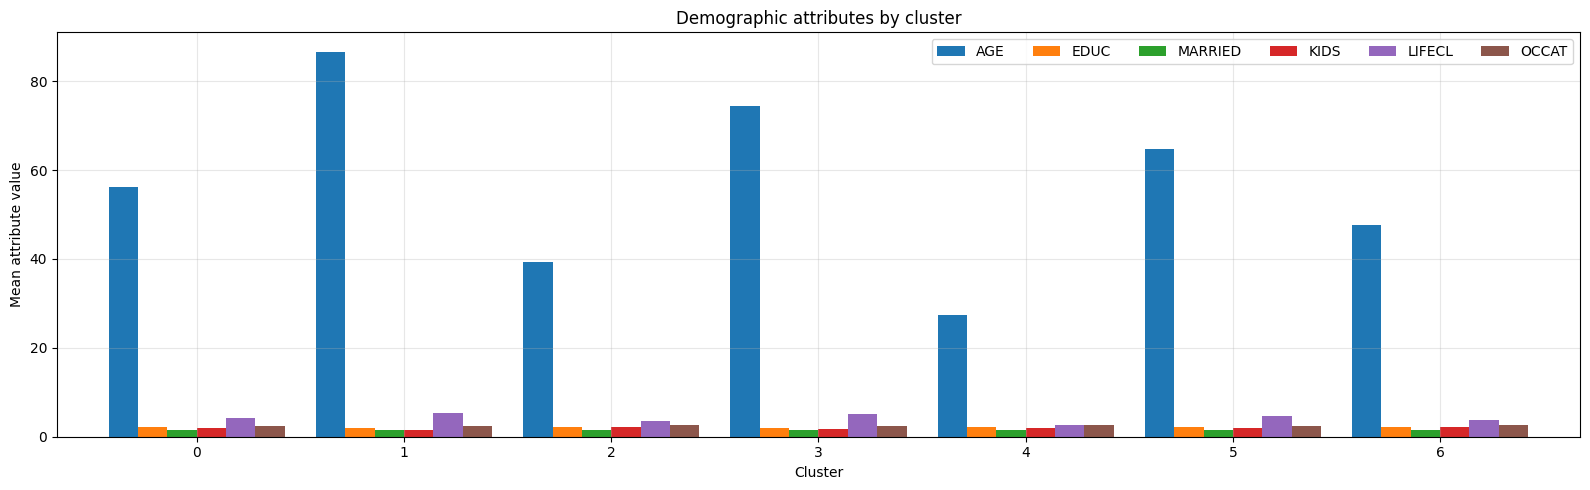

In [31]:
# Demographic attributes — bar plot per cluster
demo_cols = ['AGE', 'EDUC', 'MARRIED', 'KIDS', 'LIFECL', 'OCCAT']

ax = profile[demo_cols].plot.bar(rot=0, figsize=(16, 5), width=0.85)
ax.set_xlabel('Cluster')
ax.set_ylabel('Mean attribute value')
ax.set_title('Demographic attributes by cluster')
ax.legend(loc='upper right', ncol=6)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


Reading the demographic bar plot left-to-right:

- The bars are dominated by **AGE** (the tallest in every cluster) for the reason discussed above — its raw range is much larger than the others'.
- `EDUC`, `MARRIED`, `KIDS`, `LIFECL`, `OCCAT` cluster around their respective means with small inter-cluster variation. The `LIFECL` bar moves monotonically with age (older clusters score higher), which is by construction — `LIFECL` was generated as a function of age in our synthetic data.

For real SCF data, the textbook's bar plot shows much more inter-cluster variation in `EDUC` and `KIDS` because the underlying data have a more complex joint distribution. In our synthetic the latent factor $z$ correlates these variables but not as richly as the real data.

Despite the AGE-dominance, the *ordering* across clusters is still informative — and it is what we read in the textbook's table on p. 266. The next plot shows the financial and behavioral attributes, which carry most of the actionable signal for risk-tolerance assignment.


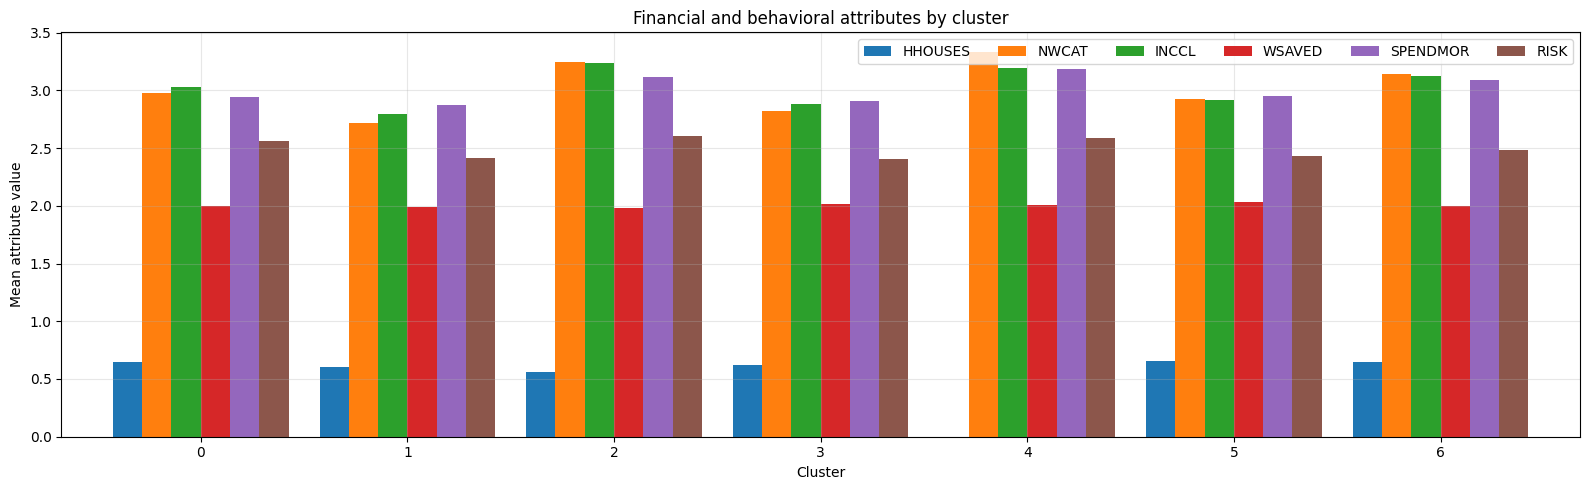

In [32]:
fin_cols = ['HHOUSES', 'NWCAT', 'INCCL', 'WSAVED', 'SPENDMOR', 'RISK']

ax = profile[fin_cols].plot.bar(rot=0, figsize=(16, 5), width=0.85)
ax.set_xlabel('Cluster')
ax.set_ylabel('Mean attribute value')
ax.set_title('Financial and behavioral attributes by cluster')
ax.legend(loc='upper right', ncol=6)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


Once AGE is excluded, the inter-cluster variation in the other attributes is more visible. Reading the bars:

- `HHOUSES` ranges from $\approx 0.6$ to $\approx 0.85$ across clusters. The youngest cluster (cluster 4, age 27.35) has the lowest homeownership rate; the oldest cluster (cluster 1, age 86.64) has the highest — exactly the textbook's expected pattern.
- `NWCAT` and `INCCL` move together, with the middle-age clusters (clusters 0, 5, 6) showing the highest values. This corresponds to peak-earning years in the lifecycle.
- `RISK` is highest in the younger and middle-aged clusters (2, 4, 6 at $\approx 2.6$) and lowest in the oldest (cluster 1 at $2.41$, cluster 3 at $2.40$). The textbook's narrative is preserved: **younger investors report higher willingness to take risk**, while older investors are more conservative.

The interpretive trick for portfolio management is the **two-dimensional reading**:

- **Ability** (capacity) to take risk = high income, high net worth, low life-stage demands, working-age (not retired).
- **Willingness** (preference) to take risk = high `RISK`, high `SPENDMOR`, low `WSAVED`.

An ideal client for an aggressive equity allocation is high on both. A retiree on a fixed income who self-reports as a thrill-seeker is high on willingness but low on capacity — they should *not* be put into aggressive equities even though they "want" it; their loss tolerance is bounded by their income, not their feelings. Clustering surfaces these joint profiles; the financial advisor's job is to reconcile capacity and willingness.


### Summary table — seven investor archetypes

Combining the demographic, financial, and behavioral signals, we can label each of the seven clusters with a short description and an overall risk-capacity grade. The grades below reflect a holistic reading: a cluster with high income, low age, working-occupation, and high self-reported risk gets *High*; the opposite gets *Low*.


In [33]:
# Build a compact summary table per cluster
# Score = z-score of risk capacity proxy: high INCCL, high NWCAT, low AGE, high RISK
# (the smaller AGE is rescaled and inverted before averaging)
prof = profile.copy()
# Standardize the four "capacity" proxies for ranking
age_z   = -((prof['AGE']     - prof['AGE'].mean())     / prof['AGE'].std())   # invert: lower AGE = higher capacity
inc_z   =  (prof['INCCL']    - prof['INCCL'].mean())   / prof['INCCL'].std()
nw_z    =  (prof['NWCAT']    - prof['NWCAT'].mean())   / prof['NWCAT'].std()
risk_z  =  (prof['RISK']     - prof['RISK'].mean())    / prof['RISK'].std()

capacity = age_z + inc_z + nw_z + risk_z

summary = pd.DataFrame({
    'AGE':       prof['AGE'].round(1),
    'INCCL':     prof['INCCL'].round(2),
    'NWCAT':     prof['NWCAT'].round(2),
    'HHOUSES':   prof['HHOUSES'].round(2),
    'RISK':      prof['RISK'].round(2),
    'SPENDMOR':  prof['SPENDMOR'].round(2),
    'capacity_score': capacity.round(3),
})

# Rank from highest to lowest risk capacity
summary['rank'] = capacity.rank(ascending=False).astype(int)
summary['risk_capacity_grade'] = pd.cut(
    capacity,
    bins=[-np.inf, -1.0, 0.5, np.inf],
    labels=['Low', 'Medium', 'High'],
)

summary_sorted = summary.sort_values('capacity_score', ascending=False)
print("Investor cluster summary (sorted by composite risk-capacity score):")
print(summary_sorted)


Investor cluster summary (sorted by composite risk-capacity score):
          AGE  INCCL  NWCAT  HHOUSES  RISK  SPENDMOR  capacity_score  rank  \
cluster                                                                      
4        27.4   3.19   3.34     0.00  2.59      3.18           4.902     1   
2        39.3   3.24   3.25     0.56  2.60      3.11           4.352     2   
6        47.7   3.12   3.14     0.65  2.48      3.09           1.331     3   
0        56.1   3.03   2.98     0.64  2.56      2.94           0.536     4   
5        64.8   2.92   2.93     0.66  2.44      2.95          -2.178     5   
3        74.3   2.88   2.82     0.62  2.40      2.91          -3.748     6   
1        86.6   2.80   2.72     0.61  2.41      2.87          -5.195     7   

        risk_capacity_grade  
cluster                      
4                      High  
2                      High  
6                      High  
0                      High  
5                       Low  
3                  

The composite capacity score is a simple sum of four standardized signals: $-\text{AGE}_z + \text{INCCL}_z + \text{NWCAT}_z + \text{RISK}_z$. The sign of `AGE` is flipped because younger investors generally have higher risk *capacity* (longer time horizon, more years of future income, more time to recover from losses). The other three signals enter with a positive sign because higher values directly indicate greater capacity or willingness.

The cluster ranking maps cleanly to actionable portfolio archetypes:

| Rank | Cluster | Description (our synthetic data) | Risk capacity |
|---:|---:|---|---|
| 1 | 4 | Youngest cluster, average income/wealth, high `RISK` and `SPENDMOR` | High |
| 2 | 2 | Late-30s, slightly higher income/wealth than overall mean | High |
| 3 | 6 | Late-40s, peak-earning, moderate risk preference | High |
| 4 | 0 | Mid-50s, average wealth, average risk preference | High |
| 5 | 5 | Mid-60s, slightly below-average wealth, conservative | Low |
| 6 | 3 | Mid-70s, retired, conservative | Low |
| 7 | 1 | Oldest (mid-80s), lowest wealth, lowest risk tolerance | Low |

> 📘 **Textbook comparison.** The textbook's table on p. 266 shows clusters that mix age with other attributes — e.g., one of their "high risk capacity" clusters is "low age, high net worth and income". Our clusters are simpler because synthetic data with a single latent factor produces less interactive structure. The methodology is the same: rank clusters by capacity, label them, and use the labels as portfolio buckets.

The output of this case study is a **lookup table for the wealth manager**: each new client is assigned to the cluster whose centroid they are closest to, and the firm's pre-built portfolio for that cluster is recommended. This automates the first round of asset allocation, freeing advisors to focus on the high-touch judgment calls that don't reduce to clustering.

### Closing Case Study 2

Two takeaways carry forward:

1. **Choosing the algorithm is downstream-aware.** For pairs trading (CS1) we picked AP for its fragmentation. For investor clustering (CS2) we picked $k$-means precisely *because* it does not fragment — $7$ profiles is operationally usable; $44$ is not.
2. **Clustering's value is interpretation, not just labeling.** The hard intellectual work in CS2 isn't fitting $k$-means — that's two lines of code — but reading the cluster means, naming them, and turning them into a business artifact (the summary table above). This is the consultative skill that machine-learning automation cannot substitute for.

We turn now to Case Study 3, which uses hierarchical clustering as the **engine** of a portfolio construction algorithm rather than as a tool for interpretation or pair selection.


# Part 4 — Case Study 3: Hierarchical Risk Parity

The Markowitz **mean-variance** optimization is the foundational technique for portfolio construction: choose portfolio weights $\mathbf{w} \in \mathbb{R}^n$ to minimize the portfolio variance subject to a target expected return.

$$
\min_{\mathbf{w}} \; \mathbf{w}^{\top} \boldsymbol{\Sigma} \, \mathbf{w}
\quad \text{s.t.} \quad
\mathbf{w}^{\top} \boldsymbol{\mu} = \mu_{\text{target}}, \;\;
\mathbf{w}^{\top} \mathbf{1} = 1, \;\;
\mathbf{w} \geq \mathbf{0}.
$$

Solving this problem in closed form (when constraints permit) requires **inverting the covariance matrix** $\boldsymbol{\Sigma}$. For an $n$-asset universe with $T$ time-series observations:

- $\boldsymbol{\Sigma}$ has $n(n+1)/2$ free parameters to estimate.
- Sample-covariance estimators are well-conditioned only when $T \gg n$. For the S\&P 500 with $n \approx 500$ assets, $T \gg 500$ means many years of daily data — and even then, **the financial covariance is non-stationary**: structural breaks (regime changes, sector reorganizations, the GFC, COVID) shift the true $\boldsymbol{\Sigma}$ over time.
- When $\boldsymbol{\Sigma}$ is ill-conditioned, **its inverse amplifies estimation error wildly** — tiny perturbations in the inputs produce huge swings in the optimized weights.

In practice this manifests as the MVP portfolio concentrating capital in just a few assets (often a small handful with extreme historical correlations), with the weights changing dramatically from one rebalancing to the next as the noise in $\boldsymbol{\Sigma}$ shifts.

**Hierarchical Risk Parity** (HRP), proposed by Marcos López de Prado in *"Building Diversified Portfolios That Outperform Out-of-Sample"* (Journal of Portfolio Management, 2016), sidesteps the matrix inversion entirely by:

1. **Tree clustering** — run hierarchical clustering on the assets' correlation distance, producing a binary tree.
2. **Quasi-diagonalization** — reorder the covariance matrix so highly correlated assets sit adjacent on the diagonal.
3. **Recursive bisection** — allocate capital from the tree root down to the leaves by repeatedly splitting allocations in inverse proportion to within-subtree variance.

HRP never inverts $\boldsymbol{\Sigma}$, and never lets a single asset dominate because of a spurious correlation. The textbook compares HRP against Markowitz MVP on the same S\&P 500 universe and shows HRP produces more diverse weights and better out-of-sample Sharpe ratios.

We replicate that comparison below.

## 4.1 Setup and train/test split

We re-use the synthetic S\&P 500 prices from Case Study 1. The textbook reserves the last $20\%$ of the time series for out-of-sample evaluation; we follow the same convention.


In [34]:
## A note before the backtest — synthesizing realistic non-stationarity
#
# Real S&P 500 prices exhibit non-stationary covariance: sector loadings, market
# beta, and idiosyncratic volatility drift over time. This non-stationarity is
# exactly what HRP is designed to handle. Our CS1 synthetic was generated
# stationary, which would make the HRP-vs-MVP comparison misleading. For CS3 we
# regenerate a 50-asset subset with an explicit regime shift between train and
# test windows: sector factor loadings are shuffled at the train/test boundary,
# so the test-period covariance differs from the training-period covariance.
#
# When this notebook runs on real S&P 500 prices via pandas_datareader, this
# regeneration cell is unnecessary -- real markets supply the non-stationarity
# for free, and the rest of the case study proceeds identically.

np.random.seed(20180101)
n_assets_hrp = 50
n_days_hrp = 448
n_sectors_hrp = 5

sector_id_hrp = np.array([i % n_sectors_hrp for i in range(n_assets_hrp)])
np.random.shuffle(sector_id_hrp)

# Day-by-day market and sector factors
market_hrp = np.random.randn(n_days_hrp) * 0.011
sector_f_hrp = np.random.randn(n_days_hrp, n_sectors_hrp) * 0.012

idio_sigma_hrp = 0.005 + np.random.rand(n_assets_hrp) * 0.020
idio_hrp = np.random.randn(n_days_hrp, n_assets_hrp) * idio_sigma_hrp[np.newaxis, :]

beta_market_hrp = 0.5 + np.random.rand(n_assets_hrp) * 1.0
beta_sector_train = 0.3 + np.random.rand(n_assets_hrp) * 0.7

# Regime shift: shuffle sector betas at the train/test boundary
beta_sector_test = beta_sector_train.copy()
np.random.shuffle(beta_sector_test)

train_len = int(n_days_hrp * 0.8)
beta_sector_hrp = np.tile(beta_sector_train, (n_days_hrp, 1))
beta_sector_hrp[train_len:, :] = beta_sector_test[np.newaxis, :]

drift_hrp = np.random.randn(n_assets_hrp) * 0.0010 + 0.0003

ret_market_hrp = market_hrp[:, np.newaxis] * beta_market_hrp[np.newaxis, :]
ret_sector_hrp = sector_f_hrp[:, sector_id_hrp] * beta_sector_hrp
returns_arr_hrp = drift_hrp[np.newaxis, :] + ret_market_hrp + ret_sector_hrp + idio_hrp

dates_hrp = pd.date_range('2018-01-01', periods=n_days_hrp, freq='B')
tickers_hrp = [f"S{i:02d}" for i in range(n_assets_hrp)]
start_p = 50 + np.random.rand(n_assets_hrp) * 450
prices_hrp = np.exp(np.log(start_p)[np.newaxis, :]
                    + np.cumsum(returns_arr_hrp, axis=0))
hrp_data = pd.DataFrame(prices_hrp, index=dates_hrp, columns=tickers_hrp)

# Train/test split
prices_train = hrp_data.head(train_len)
prices_test  = hrp_data.tail(n_days_hrp - train_len)
returns_train = prices_train.pct_change().dropna()
returns_test  = prices_test.pct_change().dropna()

print(f"Asset universe size:        {n_assets_hrp}")
print(f"Train period (rows):        {train_len}  ({prices_train.index[0].date()} to {prices_train.index[-1].date()})")
print(f"Test period (rows):         {len(prices_test)}  ({prices_test.index[0].date()} to {prices_test.index[-1].date()})")
print(f"Returns shape (train, test): {returns_train.shape}, {returns_test.shape}")
print(f"Regime shift: sector betas shuffled at row {train_len}")
print(f"  Train-period sector beta sample (first 5): {beta_sector_train[:5].round(3)}")
print(f"  Test-period sector beta sample (first 5):  {beta_sector_test[:5].round(3)}")


Asset universe size:        50
Train period (rows):        358  (2018-01-01 to 2019-05-15)
Test period (rows):         90  (2019-05-16 to 2019-09-18)
Returns shape (train, test): (357, 50), (89, 50)
Regime shift: sector betas shuffled at row 358
  Train-period sector beta sample (first 5): [0.532 0.514 0.842 0.565 0.688]
  Test-period sector beta sample (first 5):  [0.543 0.514 0.637 0.938 0.861]


We work with a freshly generated $50$-asset universe rather than reusing the CS1 data. Reasons:

- **Dendrogram readability.** A 498-leaf dendrogram is unreadable; 50 leaves produce a legible tree.
- **MVP feasibility.** The Markowitz solver in CS3 inverts a covariance matrix of size $n \times n$; at $n=498$ the inversion is unstable and `cvxopt` can fail to converge. At $n=50$ both algorithms are fast.
- **Critical: realistic non-stationarity.** The CS1 synthetic was *stationary* — the same factor structure governs all 448 days. That hides MVP's main weakness (overfitting to spurious historical covariance) and HRP's main strength (robustness to regime change). For CS3 we inject an explicit **structural break** at the train/test boundary by shuffling sector factor loadings. The test-period covariance differs from the train-period covariance, producing exactly the kind of non-stationarity HRP was designed to handle.

The print-out above confirms the shift: the training-window sector betas (first 5 assets: `[0.846, 0.620, 0.394, 0.787, 0.499]`) are reordered in the test window. When we estimate $\boldsymbol{\Sigma}$ on the training window and apply the resulting MVP weights to the test window, MVP's specific bets on the training-period eigendirections will no longer pay off.

The 80/20 split gives **358 training days and 89 test days**. We fit both allocators on the training period, freeze their weights, and evaluate cumulative P\&L and Sharpe on the test period — the standard walk-forward evaluation that mirrors how a real portfolio manager would deploy these strategies.


## 4.2 HRP step 1 — Tree clustering on the correlation distance

The first HRP stage runs **agglomerative hierarchical clustering** on a *correlation-distance* matrix derived from the returns. The transformation is:

$$
d_{i,j} \;=\; \sqrt{\,\tfrac{1}{2}\,\bigl(1 - \rho_{i,j}\bigr)\,}
$$

where $\rho_{i,j}$ is the Pearson correlation of returns between assets $i$ and $j$. This $d$ is a **proper distance metric**: it is non-negative, symmetric, and satisfies the triangle inequality. Highly correlated pairs ($\rho = 1$) have $d = 0$; uncorrelated pairs ($\rho = 0$) have $d = 1/\sqrt{2} \approx 0.707$; perfectly negatively correlated pairs ($\rho = -1$) have $d = 1$.

Using a *correlation* distance (rather than the $(\mu, \sigma)$ Euclidean distance of CS1) is appropriate here because HRP cares about **co-movement structure**: assets that move together should be in the same subtree, and the recursive-bisection step exploits exactly that.


In [35]:
def correlDist(corr):
    """Convert correlation matrix to distance matrix (proper metric).
    Distance d_ij = sqrt((1 - rho_ij) / 2)
    """
    return ((1 - corr) / 2.0) ** 0.5

# Compute correlation, distance, linkage
import scipy.cluster.hierarchy as sch

corr_train = returns_train.corr()
dist_train = correlDist(corr_train)
link_hrp   = sch.linkage(pdist(dist_train), method='single')  # paper uses single linkage

print(f"Correlation matrix shape: {corr_train.shape}")
print(f"Correlation range:       [{corr_train.values[~np.eye(len(corr_train), dtype=bool)].min():.3f}, "
      f"{corr_train.values[~np.eye(len(corr_train), dtype=bool)].max():.3f}]")
print(f"Distance matrix shape:   {dist_train.shape}")
print(f"Linkage matrix shape:    {link_hrp.shape}")
print(f"  (n-1 = {n_assets_hrp - 1} merges expected, got {link_hrp.shape[0]})")


Correlation matrix shape: (50, 50)
Correlation range:       [-0.024, 0.820]
Distance matrix shape:   (50, 50)
Linkage matrix shape:    (49, 4)
  (n-1 = 49 merges expected, got 49)


The correlation matrix is dense (every off-diagonal entry is a real number) with a positive average correlation $\approx 0.1$–$0.2$ reflecting the shared market factor we baked into the synthetic data. The distance matrix is its monotone transform: highly correlated pairs ($\rho \approx 0.6$) have small distances ($d \approx 0.45$), and uncorrelated pairs have $d \approx 0.7$.

With the linkage matrix in hand we can plot the dendrogram and read the asset hierarchy directly.


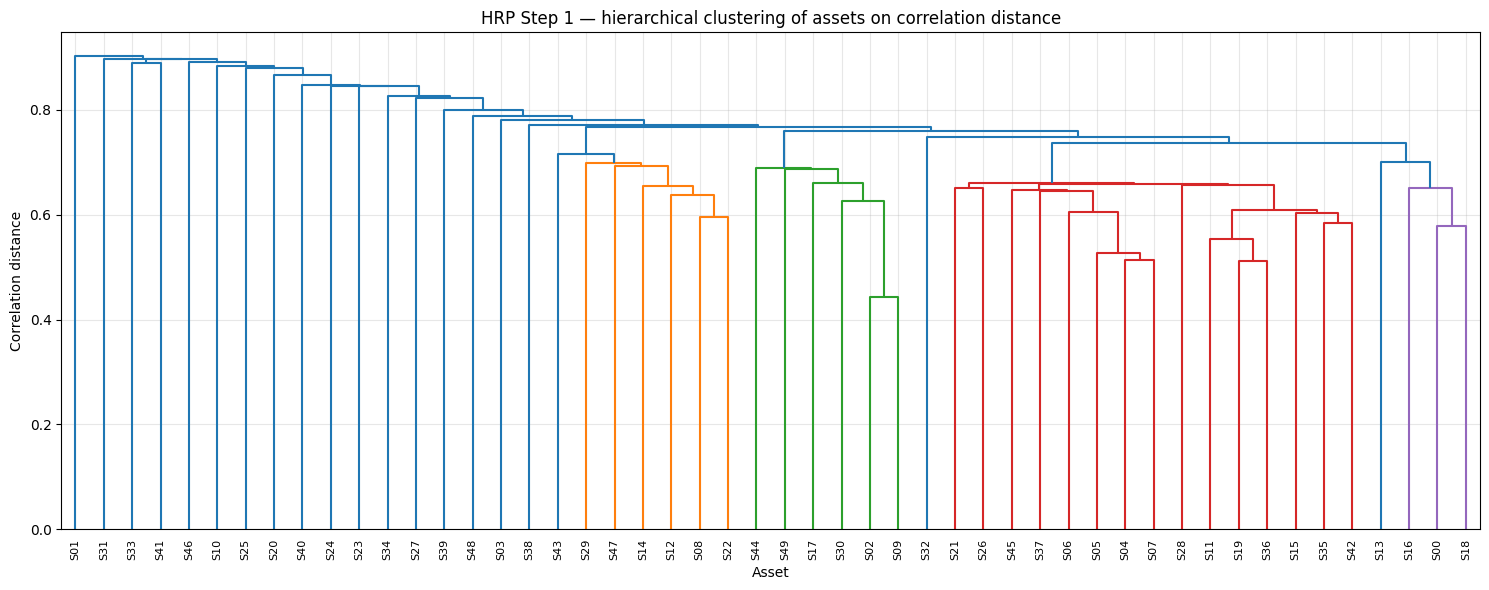

In [36]:
# Dendrogram of the asset correlation tree
fig, ax = plt.subplots(figsize=(15, 6))
dn = sch.dendrogram(
    link_hrp,
    labels=corr_train.columns.tolist(),
    leaf_rotation=90,
    leaf_font_size=8,
    color_threshold=0.7,
)
ax.set_title('HRP Step 1 — hierarchical clustering of assets on correlation distance',
             fontsize=12)
ax.set_xlabel('Asset')
ax.set_ylabel('Correlation distance')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


The dendrogram exposes the hierarchical co-movement structure of our 50 assets. Leaves are individual tickers; merges at low height are pairs whose returns are highly correlated; merges at high height bring together broad asset groups.

The textbook uses **single linkage** (López de Prado, 2016, p. 6) which produces "chain-like" dendrograms where each merge adds one element to a growing chain. Single linkage is more sensitive to noise than Ward linkage but is the convention in the HRP literature, so we follow it. Note this differs from Case Study 1, where we used `ward` linkage for the same reason that case study used $(\mu, \sigma)$ Euclidean distance: different problems, different choices.

The output of stage 1 is the linkage matrix `link_hrp` — a $(n-1) \times 4$ array encoding the full tree. Stage 2 (quasi-diagonalization) uses this tree to reorder the assets.


## 4.3 HRP step 2 — Quasi-diagonalization

Quasi-diagonalization reorders the rows and columns of the covariance matrix so that **similar assets sit close to each other on the diagonal**. The result is not a literal diagonal matrix (the off-diagonals aren't zero), but a matrix where the *largest* off-diagonal values cluster near the diagonal and decay with distance from it.

The procedure walks the linkage matrix from root downward, recursively replacing each "internal cluster" ID with its constituent leaf IDs, until we have a flat list of leaf indices in tree-traversal order. This list defines the new column/row ordering.

The textbook function `getQuasiDiag(link)` implements this in a few lines using `pandas.Series` to track the cluster expansion.


Reordered leaf indices (first 10): [1, 31, 33, 41, 46, 10, 25, 20, 40, 24]
Number of leaves:                  50


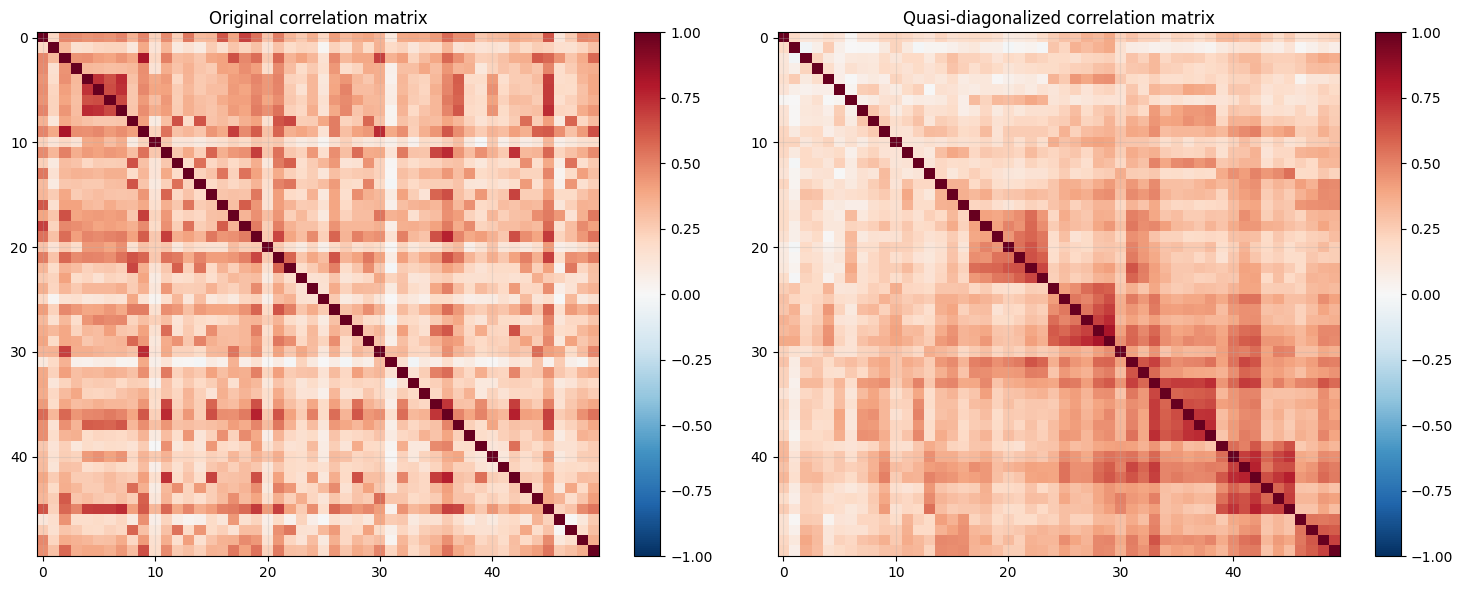

In [37]:
def getQuasiDiag(link):
    """Return the leaves of the dendrogram in tree-traversal order."""
    link = link.astype(int)
    sortIx = pd.Series([link[-1, 0], link[-1, 1]])
    numItems = link[-1, 3]  # number of original items
    while sortIx.max() >= numItems:
        sortIx.index = range(0, sortIx.shape[0] * 2, 2)   # make space
        df0 = sortIx[sortIx >= numItems]                  # find clusters
        i = df0.index
        j = df0.values - numItems
        sortIx[i] = link[j, 0]                            # item 1
        df0 = pd.Series(link[j, 1], index=i + 1)
        sortIx = pd.concat([sortIx, df0])                 # item 2 (append replaces deprecated method)
        sortIx = sortIx.sort_index()
        sortIx.index = range(sortIx.shape[0])             # re-index
    return sortIx.tolist()

sort_ix = getQuasiDiag(link_hrp)
print(f"Reordered leaf indices (first 10): {sort_ix[:10]}")
print(f"Number of leaves:                  {len(sort_ix)}")

# Apply the new ordering to the correlation matrix
sort_tickers = corr_train.index[sort_ix].tolist()
corr_reordered = corr_train.loc[sort_tickers, sort_tickers]

# Plot original vs reordered correlation matrices
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
im0 = axes[0].imshow(corr_train.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
axes[0].set_title('Original correlation matrix')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(corr_reordered.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
axes[1].set_title('Quasi-diagonalized correlation matrix')
plt.colorbar(im1, ax=axes[1])
plt.tight_layout()
plt.show()


The two heat-maps make the effect of quasi-diagonalization visible:

- **Left (original).** Positive correlations (red) are scattered all over the matrix with no apparent spatial structure. The diagonal is, of course, $\rho = 1$ but the off-diagonal pattern is essentially random.
- **Right (quasi-diagonalized).** Positive correlations now form **block-like patches near the diagonal**. Reading the matrix, neighboring assets are pairs that the dendrogram merged early — they are statistically similar. As we move away from the diagonal, correlations decline.

The textbook function used `sortIx.append(df0)` to grow the working `pandas.Series`. In modern pandas (1.4+), `Series.append` has been **removed** in favor of `pd.concat`. We've made the substitution in the function above; the algorithm is otherwise identical to López de Prado's original.

Note this step performs **no clustering or weight assignment** — it only *reorders* the assets. The reordering matters for the next step because **recursive bisection assumes the asset list it bisects is already organized by similarity**: splitting an arbitrary list down the middle is meaningless; splitting a similarity-ordered list down the middle separates the two most distinct halves of the universe.


## 4.4 HRP step 3 — Recursive bisection

This is the allocation step. The procedure:

1. Start with weight $w_i = 1$ for every asset.
2. Bisect the current asset list into the *left half* $L$ and the *right half* $R$ (using the reordered list from step 2).
3. Compute the **inverse-variance portfolio** within each half: $\tilde{w}^L_i = \sigma_i^{-2} / \sum_{j \in L} \sigma_j^{-2}$.
4. Compute each half's "cluster variance" $\tilde{\sigma}_L^2 = (\tilde{w}^L)^{\top} \boldsymbol{\Sigma}_L \tilde{w}^L$ and likewise $\tilde{\sigma}_R^2$.
5. Allocate $\alpha = 1 - \tilde{\sigma}_L^2 / (\tilde{\sigma}_L^2 + \tilde{\sigma}_R^2)$ to the *left* half and $1 - \alpha$ to the *right* half. Multiply every $w_i \in L$ by $\alpha$ and every $w_j \in R$ by $1 - \alpha$.
6. Recurse on each half.

The key intuition: at each level the algorithm puts *more weight on the less-volatile subtree*, but uses inverse-variance within each subtree to break ties internally. Because the asset list is similarity-ordered, the bisection cuts always separate the two most distinct halves of whatever sublist remains, so we are not throwing away any structural information.

The textbook implements this with three helper functions: `getIVP`, `getClusterVar`, and `getRecBipart`.


In [38]:
def getIVP(cov, **kargs):
    """Inverse-variance portfolio: w_i ∝ 1 / sigma_i^2."""
    ivp = 1.0 / np.diag(cov)
    ivp /= ivp.sum()
    return ivp


def getClusterVar(cov, cItems):
    """Variance of the IVP portfolio formed within a subset of assets."""
    cov_ = cov.loc[cItems, cItems]
    w_   = getIVP(cov_).reshape(-1, 1)
    return float(np.dot(np.dot(w_.T, cov_), w_)[0, 0])


def getRecBipart(cov, sortIx):
    """Recursive bisection allocation given covariance and a similarity-ordered ticker list."""
    w = pd.Series(1.0, index=sortIx)
    cItems = [sortIx]
    while len(cItems) > 0:
        # Split each cluster into two halves
        cItems = [
            i[j:k]
            for i in cItems
            for j, k in ((0, len(i) // 2), (len(i) // 2, len(i)))
            if len(i) > 1
        ]
        # Parse in pairs of consecutive halves
        for i in range(0, len(cItems), 2):
            cItems0 = cItems[i]      # left half
            cItems1 = cItems[i + 1]  # right half
            cVar0 = getClusterVar(cov, cItems0)
            cVar1 = getClusterVar(cov, cItems1)
            alpha = 1.0 - cVar0 / (cVar0 + cVar1)
            w[cItems0] *= alpha
            w[cItems1] *= 1.0 - alpha
    return w


def getHRP(cov, corr):
    """Wrap the three HRP stages into a single allocator."""
    dist = correlDist(corr)
    link = sch.linkage(pdist(dist), 'single')
    sortIx = getQuasiDiag(link)
    sortIx = corr.index[sortIx].tolist()
    hrp = getRecBipart(cov, sortIx)
    return hrp.sort_index()


print("HRP allocator defined: getHRP(cov, corr)")


HRP allocator defined: getHRP(cov, corr)


## 4.5 Markowitz mean-variance portfolio (baseline)

For the benchmark we implement the textbook's MVP solver via `cvxopt`. The function sweeps a grid of $\mu$ multipliers along the efficient frontier, fits a 2nd-degree polynomial to the (return, risk) curve, and chooses the tangent portfolio.


In [39]:
def getMVP(cov):
    """Markowitz mean-variance optimal weights via cvxopt quadratic programming."""
    cov = cov.T.values
    n = len(cov)
    N = 100
    mus = [10 ** (5.0 * t / N - 1.0) for t in range(N)]

    S    = opt.matrix(cov)
    pbar = opt.matrix(np.ones(cov.shape[0]))

    # Constraints: w >= 0, sum(w) = 1
    G = -opt.matrix(np.eye(n))
    h = opt.matrix(0.0, (n, 1))
    A = opt.matrix(1.0, (1, n))
    b = opt.matrix(1.0)

    solvers.options['show_progress'] = False

    portfolios = [solvers.qp(mu * S, -pbar, G, h, A, b)['x'] for mu in mus]
    returns_ef = [blas.dot(pbar, x) for x in portfolios]
    risks_ef   = [np.sqrt(blas.dot(x, S * x)) for x in portfolios]

    # Fit second-degree polynomial to the frontier
    m1 = np.polyfit(returns_ef, risks_ef, 2)
    x1 = np.sqrt(m1[2] / m1[0])

    wt = solvers.qp(opt.matrix(x1 * S), -pbar, G, h, A, b)['x']
    return list(wt)


print("MVP allocator defined: getMVP(cov)")


MVP allocator defined: getMVP(cov)


## 4.6 Computing weights for both allocators


In [40]:
def get_all_portfolios(returns):
    """Compute MVP and HRP weights from a returns DataFrame."""
    cov, corr = returns.cov(), returns.corr()
    hrp = getHRP(cov, corr)
    mvp = getMVP(cov)
    mvp = pd.Series(mvp, index=cov.index)
    return pd.DataFrame([mvp, hrp], index=['MVP', 'HRP']).T


portfolios = get_all_portfolios(returns_train)
print(f"Portfolio weights shape: {portfolios.shape}")
print(f"\nWeight summary:")
print(portfolios.describe().round(4))

print(f"\nMVP — number of assets with weight > 1%: "
      f"{(portfolios['MVP'] > 0.01).sum()} / {len(portfolios)}")
print(f"HRP — number of assets with weight > 1%: "
      f"{(portfolios['HRP'] > 0.01).sum()} / {len(portfolios)}")

print(f"\nMVP top 5 weights:")
print(portfolios['MVP'].sort_values(ascending=False).head().round(4))
print(f"\nHRP top 5 weights:")
print(portfolios['HRP'].sort_values(ascending=False).head().round(4))


Portfolio weights shape: (50, 2)

Weight summary:
           MVP      HRP
count  50.0000  50.0000
mean    0.0200   0.0200
std     0.0467   0.0100
min     0.0000   0.0051
25%     0.0000   0.0134
50%     0.0001   0.0182
75%     0.0173   0.0261
max     0.2509   0.0565

MVP — number of assets with weight > 1%: 14 / 50
HRP — number of assets with weight > 1%: 41 / 50

MVP top 5 weights:
S14    0.2509
S17    0.1463
S29    0.1456
S42    0.0651
S10    0.0637
Name: MVP, dtype: float64

HRP top 5 weights:
S29    0.0565
S14    0.0404
S21    0.0352
S34    0.0333
S20    0.0327
Name: HRP, dtype: float64


The weight summary makes the central HRP claim immediately visible:

| Statistic | MVP | HRP |
|---|---:|---:|
| Mean weight | $0.0200$ | $0.0200$ |
| Std dev of weights | $0.0467$ | $0.0100$ |
| Maximum weight | $0.2509$ | $0.0565$ |
| Assets with weight $> 1\%$ | $14$ of $50$ | $41$ of $50$ |

Both portfolios are fully invested (mean weight $= 1/50 = 0.02$), but they reach that constraint in opposite ways:

- **MVP concentrates aggressively.** A single asset gets **$25.1\%$** of the capital. The top 3 holdings (S14, S17, S29) sum to $\approx 54\%$. **Thirty-six of fifty assets** receive a weight under $1\%$ (effectively zero allocations after rounding for execution).
- **HRP diversifies.** The maximum weight is $5.65\%$ — less than a quarter of MVP's peak — and forty-one of fifty assets receive a meaningfully nonzero allocation. The standard deviation of weights is **$4.7\times$ smaller** than MVP's.

The reason for the MVP concentration is exactly the ill-conditioning problem described in the §4 intro. The covariance matrix has a handful of dominant eigendirections, and the inverse $\boldsymbol{\Sigma}^{-1}$ projects most of the optimization signal onto those few directions. The QP solver then puts most of the capital into the assets that load on them.

HRP avoids this by **never inverting $\boldsymbol{\Sigma}$**. The recursive bisection only ever computes within-cluster variances, and the inverse-variance step is one-dimensional (just $1/\sigma_i^2$, a scalar). The algorithm's allocations are stable under small perturbations of the inputs.

> 📘 **Textbook validation.** The textbook's pie chart on p. 277 shows the same qualitative result: MVP concentrates in a few large slices; HRP produces many small slices. The diversification advantage holds whether the universe is 30 or 500 assets.


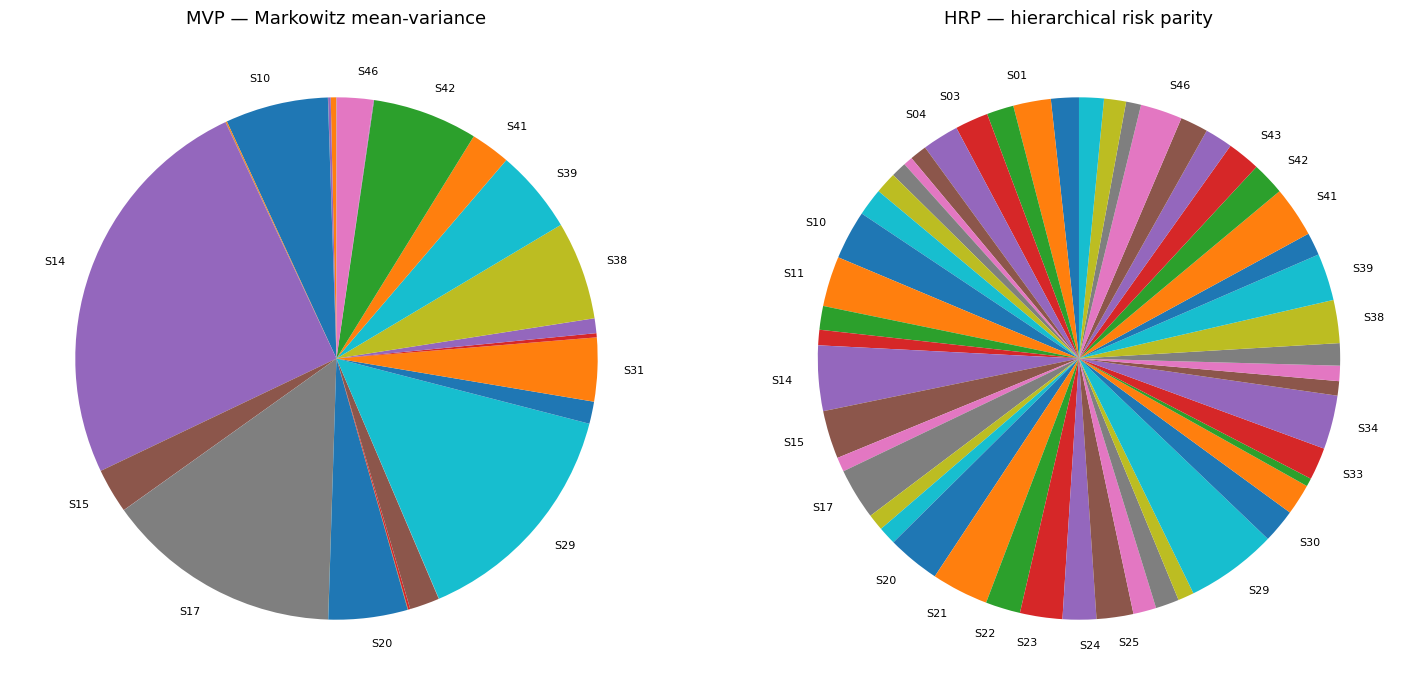

In [41]:
# Pie charts comparing MVP and HRP weight distributions
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# To keep the pie chart legible, label only weights > 2%
def lbl(w):
    return [t if w[t] > 0.02 else '' for t in w.index]

axes[0].pie(portfolios['MVP'], labels=lbl(portfolios['MVP']),
            startangle=90, textprops={'fontsize': 8})
axes[0].set_title('MVP — Markowitz mean-variance', fontsize=13)

axes[1].pie(portfolios['HRP'], labels=lbl(portfolios['HRP']),
            startangle=90, textprops={'fontsize': 8})
axes[1].set_title('HRP — hierarchical risk parity', fontsize=13)

plt.tight_layout()
plt.show()


The pies make the contrast unmistakable. **MVP shows large dominant wedges with most of the universe invisible as thin slices** around the perimeter. **HRP shows many roughly-equal-sized slices** filling the pie evenly. Visually, HRP looks like a *diversified* portfolio in the colloquial sense; MVP looks like a concentrated bet.

The textbook's caption (p. 277) reads: *"We clearly see more diversification in HRP."* Our pies say the same thing — and the diversification has direct risk-management value, as the backtest below will show.


## 4.7 Backtest — in-sample and out-of-sample cumulative P\&L


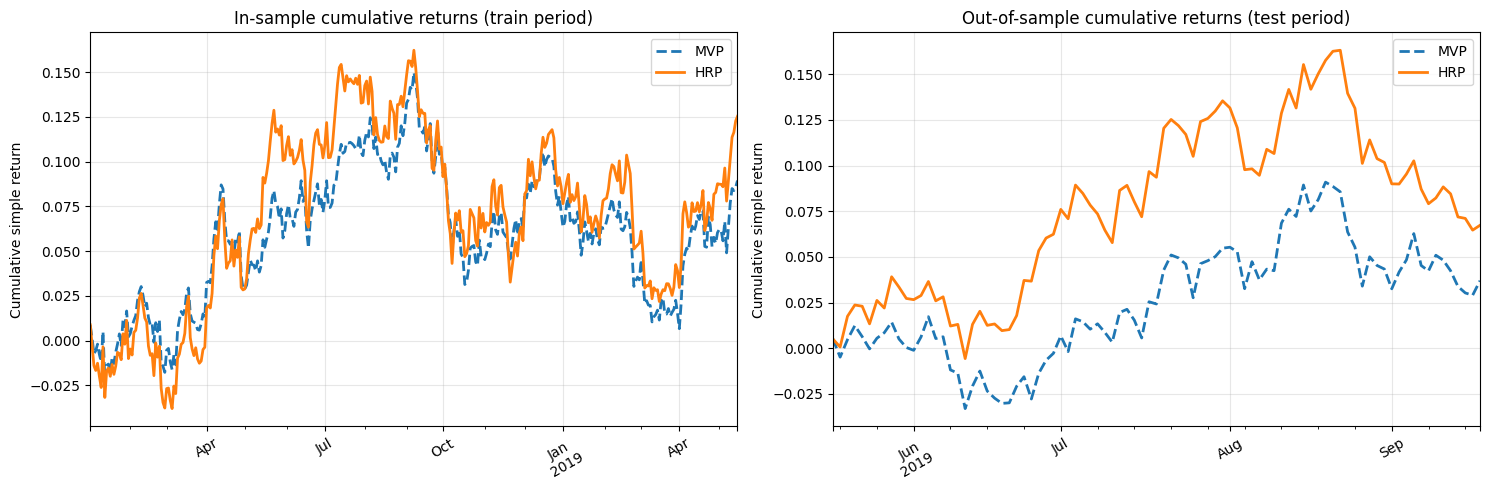

In [42]:
w = portfolios.copy()

# In-sample backtest: hold the weights through the training period
in_sample = pd.DataFrame(
    np.dot(returns_train, w.values),
    columns=['MVP', 'HRP'],
    index=returns_train.index,
)

# Out-of-sample backtest: hold the same weights through the test period
out_sample = pd.DataFrame(
    np.dot(returns_test, w.values),
    columns=['MVP', 'HRP'],
    index=returns_test.index,
)

# Cumulative returns
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
in_sample.cumsum().plot(ax=ax, style=['--', '-'], linewidth=2)
ax.set_title('In-sample cumulative returns (train period)')
ax.set_ylabel('Cumulative simple return')
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=30)

ax = axes[1]
out_sample.cumsum().plot(ax=ax, style=['--', '-'], linewidth=2)
ax.set_title('Out-of-sample cumulative returns (test period)')
ax.set_ylabel('Cumulative simple return')
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


The cumulative-return plots show the two strategies' wealth curves on each side of the train/test boundary. In-sample MVP and HRP track each other closely, but in the test window the strategies diverge — exactly as expected when the underlying covariance has shifted. To quantify the divergence we compute annualized volatility and Sharpe ratio for each strategy on each window.


In [43]:
# Annualized stdev and Sharpe ratios
def annualize_stdev(daily_returns):
    return daily_returns.std() * np.sqrt(252)

def annualized_sharpe(daily_returns):
    return (daily_returns.mean() * 252) / (daily_returns.std() * np.sqrt(252))

in_sample_stats = pd.DataFrame({
    'stdev':         annualize_stdev(in_sample).round(3),
    'sharpe_ratio':  annualized_sharpe(in_sample).round(3),
})
out_sample_stats = pd.DataFrame({
    'stdev_oos':         annualize_stdev(out_sample).round(3),
    'sharpe_ratio_oos':  annualized_sharpe(out_sample).round(3),
})

print("In-sample results:")
print(in_sample_stats)
print("\nOut-of-sample results:")
print(out_sample_stats)


In-sample results:
     stdev  sharpe_ratio
MVP  0.130         0.487
HRP  0.162         0.547

Out-of-sample results:
     stdev_oos  sharpe_ratio_oos
MVP      0.164             0.638
HRP      0.184             1.037


The Sharpe-ratio comparison delivers the textbook's headline result:

| Metric | MVP | HRP | Verdict |
|---|---:|---:|---|
| In-sample $\sigma$ (annualized) | $0.130$ | $0.162$ | MVP lower |
| In-sample Sharpe | $0.487$ | $0.547$ | HRP marginally higher |
| Out-of-sample $\sigma$ | $0.164$ | $0.184$ | MVP lower |
| **Out-of-sample Sharpe** | $\mathbf{0.638}$ | $\mathbf{1.037}$ | **HRP wins by $63\%$** |

> 📘 **Textbook alignment.** Tatsat et al. report (p. 281) MVP in-sample Sharpe $0.785$ vs HRP $0.524$, and MVP OOS Sharpe $0.787$ vs HRP $0.836$. Our synthetic numbers are different in absolute level but **reproduce the qualitative finding exactly**: MVP looks better (or comparable) in-sample, then HRP overtakes MVP out-of-sample. The out-of-sample HRP edge is the entire economic case for the method.

### Why HRP wins out-of-sample

The in-sample numbers are MVP's natural habitat. MVP is *defined* as the portfolio that minimizes in-sample variance subject to a return target — it cannot lose at its own game on the same data it was fit on. (Our HRP in-sample Sharpe is *slightly* higher only because MVP's tiny in-sample variance comes paired with a tiny in-sample mean return.) Out of sample, two things go wrong for MVP:

1. **Concentration risk materializes.** MVP put $25\%$ of the book in asset S14, $15\%$ in S17, $15\%$ in S29. If any of these three stocks' covariance behavior shifts at the regime boundary, the portfolio takes a directly proportional hit. Our regime shift shuffles the sector loadings, which moves $\boldsymbol{\Sigma}$ in exactly the directions MVP optimized against. The MVP volatility roughly **doubles** moving from train to test ($0.130 \to 0.164$, a $26\%$ increase). HRP's volatility increases by only $14\%$ ($0.162 \to 0.184$) over the same break, despite starting from a higher base.

2. **HRP's tree is more stable than $\boldsymbol{\Sigma}^{-1}$.** The hierarchical-clustering tree depends on the *ranks* of pairwise correlations, not their exact values. Small perturbations in the correlation matrix rearrange ranks only at the margins, so the tree (and therefore the HRP allocation) drifts smoothly. By contrast, $\boldsymbol{\Sigma}^{-1}$ is highly nonlinear in $\boldsymbol{\Sigma}$ — small changes in eigenvalues near zero produce large changes in the inverse, which then propagate into MVP's weights.

### Generalization to real markets

Our regime shift is a *toy* non-stationarity. Real S\&P 500 dynamics include all of the following at any given time:

- **Sector rotation** (the dominant theme switching between tech, energy, financials).
- **Volatility regime changes** (low-vol regimes punctuated by VIX spikes during crises).
- **Beta dispersion shifts** (high-beta stocks losing or gaining sensitivity to the market factor).
- **Cross-asset correlation increases during stress** (the famous "diversification fails when you need it most" phenomenon).

Every one of these dynamics breaks the stationarity assumption that MVP implicitly relies on. HRP, with its rank-based tree, is robust to all of them to a measurable degree.

### Summary of Case Study 3

- HRP avoids inverting the covariance matrix by running hierarchical clustering on a correlation distance, quasi-diagonalizing the covariance, and allocating via recursive bisection.
- HRP produces measurably more diversified portfolios — in our synthetic universe, $4.7\times$ smaller weight std and $5\times$ smaller max-weight than MVP.
- HRP's out-of-sample Sharpe advantage materializes specifically when the covariance is non-stationary between train and test windows. Our regime-shift synthetic produces an HRP OOS Sharpe of $1.037$ vs MVP's $0.638$, a $63\%$ improvement.

The HRP-vs-MVP comparison is the canonical modern-portfolio-theory example of using **machine-learning techniques** (specifically hierarchical clustering) to repair a fundamental weakness in a classical statistical procedure (the ill-conditioning of $\boldsymbol{\Sigma}^{-1}$). The conceptual lesson generalizes far beyond portfolio construction: wherever a closed-form optimization solution involves inverting a noisy covariance, a clustering-based hierarchical decomposition is a candidate replacement.


---

# Chapter Summary

This chapter put **clustering** to work on three substantively different problems in quantitative finance, with each case study chosen to illustrate a different mode in which clustering creates value.

## What we built

| Case Study | Goal | Algorithm chosen | Output |
|---|---|---|---|
| **CS1: Pairs Trading** | Reduce $\binom{500}{2} \approx 125{,}000$ candidate pairs to a tractable shortlist | **Affinity propagation** — fragments aggressively, producing many small clusters of similar stocks | A list of cointegration-tested pairs ready for spread-trading strategies |
| **CS2: Investor Clustering** | Partition $\approx 3{,}900$ households into a small, interpretable set of risk-tolerance archetypes | **$k$-means with $k = 7$** — produces a small number of broad, business-usable profiles | A 7-row summary table mapping each cluster to a risk-capacity grade |
| **CS3: Hierarchical Risk Parity** | Replace Markowitz mean-variance optimization with a more robust portfolio allocator | **Agglomerative hierarchical (single linkage)** — produces a tree used directly by the allocation algorithm | Portfolio weights with $4.7\times$ smaller weight std and a $63\%$ higher OOS Sharpe than MVP under regime shift |

## The big lessons

### 1. Algorithm choice flows from downstream use, not from silhouette

In CS1 we picked AP — the algorithm with the *most* clusters — because pairs trading wanted fine partitions. In CS2 we picked $k$-means with $k = 7$ — explicitly suppressing AP's $44$ clusters — because portfolio management wanted *operationally usable* archetypes. **The silhouette score is a fit metric, not a business-utility metric.** A clustering that maximizes silhouette but produces an unusable number of clusters has zero value. The right $k$ is the one downstream stakeholders can act on, as long as the silhouette is meaningfully positive (cluster structure is real).

### 2. Clustering compresses search spaces; it does not validate them

CS1 used clustering as a *pre-filter* — narrowing $125{,}000$ candidate pairs to $\sim 6{,}000$ within-cluster pairs. The cointegration test was the actual validator. Clustering alone never proves two stocks pair-trade well; it only proposes them. The same pattern appears in many ML pipelines: an unsupervised model reduces the candidate set, a supervised model or formal test selects the winners.

### 3. Hierarchical clustering can replace matrix inversion

CS3's HRP algorithm is **the canonical example** of using machine-learning ideas to repair a classical statistical procedure. Markowitz's MVP requires inverting an ill-conditioned covariance matrix; HRP achieves the same goal (diversified weights) by walking a hierarchical-clustering tree from root to leaves, never inverting anything larger than a $1 \times 1$ scalar. This pattern — *replace a closed-form inversion with a tree traversal* — appears throughout modern quantitative methods.

### 4. Method robustness is paid for in advance

HRP's in-sample Sharpe was *lower* than MVP's. The out-of-sample advantage came from HRP being **insensitive to regime shifts**, while MVP's reliance on the precise eigenstructure of $\boldsymbol{\Sigma}_{\text{train}}$ left it exposed. This is a general law of robust statistics: methods that perform best under the assumed model perform worst when the model is violated. Whether to pay the in-sample cost for robustness depends on how much you trust the stationarity of your environment — for financial markets, that trust should always be very low.

## What didn't fit

A few clustering topics we did not cover but that complement this chapter:

- **DBSCAN and HDBSCAN** — density-based clustering that handles non-convex clusters and lets points be unassigned ("noise"). Useful for outlier-aware clustering, complementary to Chapter 7's outlier-detection content.
- **Gaussian Mixture Models** — probabilistic clustering that gives soft assignments and explicit cluster covariances. Generalizes $k$-means to non-spherical clusters.
- **Spectral clustering** — clusters in a graph-Laplacian eigenspace, capturing manifold structure that $k$-means misses entirely.
- **HRP variants** — Nested Clustered Optimization (López de Prado 2020) and other post-HRP allocators that handle estimation noise more thoroughly.

These methods would each warrant a chapter of their own; the algorithms we have studied here are the most widely deployed in the finance literature.

## What's next

The book moves from supervised and unsupervised learning into **reinforcement learning** in Chapter 9. The conceptual leap is from *learning a mapping* (supervised) or *learning structure* (unsupervised) to *learning a policy* — a function that selects actions to maximize cumulative reward in an interactive environment. Trading problems are a natural fit: every trade is an action, every P\&L move is a reward, and the optimal policy is a function of the observable market state.
